before 30/11: weekends and weekdays were split to visualize any possible differences. No notable differences in trends in both cases were found, so they were merged!

the 'worst and best' performing stations are based on the on-time arrivals and their rankings are taken from https://www.ontimetrains.co.uk/stations

## This is demo for the assessment of one station's performance over the yearly available data

It includes a mean delay vs tph per platform as well as an outliers focus

In [ ]:
# Import required libraries for station_view function
import pandas as pd
import numpy as np
import os
import glob
from datetime import datetime, timedelta
import sys
import matplotlib.pyplot as plt

# Ensure project root is in Python path
project_root = os.path.dirname(os.getcwd())  # Go up from demos to RDM_analysis
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Force reload of the module to get updated function signatures
import importlib
if 'rdmpy.outputs.utils' in sys.modules:
    import rdmpy.outputs.utils
    importlib.reload(rdmpy.outputs.utils)
    print("✅ Reloaded rdmpy.outputs.utils module")

if 'rdmpy.outputs.load_data' in sys.modules:
    import rdmpy.outputs.load_data
    importlib.reload(rdmpy.outputs.load_data)
    print("✅ Reloaded rdmpy.outputs.load_data module")

try:
    from rdmpy.outputs.load_data import load_processed_data
    from rdmpy.outputs.utils import station_view_yearly, plot_trains_in_system_vs_delay, explore_delay_outliers
    print("✅ Libraries imported successfully for station_view analysis")
    print("✅ Trains in system vs delay function imported: plot_trains_in_system_vs_delay")
    print("✅ Delay outliers analysis function imported: explore_delay_outliers")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("Make sure you're running from the RDM_analysis directory")
except Exception as e:
    print(f"❌ Error: {e}")

station_view_yearly function ready!
plot_arrival_hour_distributions_violin function ready!
plot_variable_relationships function ready!
plot_trains_in_system_vs_delay function ready!
explore_delay_outliers function ready!
✅ Reloaded outputs.utils module
✅ Reloaded outputs.load_data module
✅ Libraries imported successfully for station_view analysis
✅ Trains in system vs delay function imported: plot_trains_in_system_vs_delay
✅ Delay outliers analysis function imported: explore_delay_outliers


Loading processed data

In [6]:
from outputs.load_data import load_processed_data

all_data = load_processed_data()

✅ Loaded 10,529,736 rows from 2606 files. Skipped 0.


In [58]:
# Test the updated yearly analysis function
incident_summary, normal_summary = station_view_yearly(
    station_id='33087', 
    interval_minutes=60
)

# Display the results
print(" YEARLY STATION ANALYSIS RESULTS:")
print("=" * 80)

if incident_summary is not None and len(incident_summary) > 0:
    print("\n🔴 INCIDENT OPERATIONS:")
    print("-" * 40)
    print(incident_summary.to_string(index=False))
    print(f"Total incident periods: {len(incident_summary)}")
    
if normal_summary is not None and len(normal_summary) > 0:
    print("\n🟢 NORMAL OPERATIONS:")
    print("-" * 40)
    print(normal_summary.to_string(index=False))
    print(f"Total normal periods: {len(normal_summary)}")

print("=" * 80)

Loaded 10373 records from MO.parquet
Loaded 9560 records from TU.parquet
Loaded 9498 records from WE.parquet
Loaded 9745 records from TH.parquet
Loaded 9183 records from FR.parquet
Loaded 7395 records from SA.parquet
Loaded 2744 records from SU.parquet
Total combined records: 58498
Incident-related records: 2440
Normal operations records: 3201
Incident-related records: 2440
Normal operations records: 3201
 YEARLY STATION ANALYSIS RESULTS:

🔴 INCIDENT OPERATIONS:
----------------------------------------
time_period  ontime_arrival_count  delayed_arrival_count  cancellation_count                                                                                                                                                                                                                                                                                                                                                                                                                                

Worst performing stations

Running trains in system vs delay analysis...
🚂 TRAINS IN SYSTEM vs DELAY ANALYSIS FOR STATION 32000
📊 Platforms: 14, Assumed Dwell Time: 5 min
📏 Trains in system NORMALIZED by 14 platforms
📏 ONE POINT PER HOUR (same as plot_variable_relationships)
⚠️  DELAY calculated ONLY from delayed trains (delay > 0)
Loaded 217738 total records for station 32000
Using 214264 arrived trains
Loaded 217738 total records for station 32000
Using 214264 arrived trains
Created 214264 valid timestamps
Created 214264 valid timestamps

✅ Processed 7392 hours total (weekdays and weekends merged)

📊 STATION 32000 - DELAY vs TRAINS IN SYSTEM (ALL DAYS)

DATA SUMMARY:
  - Total hours analyzed: 7392
  - Normalized trains in system range: 0.071 - 1.643 trains/platform
  - Mean delay range: 0.00 - 30.00 minutes
  - Overall mean delay: 6.07 minutes
  - Hours with delays > 0: 5994 (81.1%)
  - Correlation (trains in system vs delay): 0.254

✅ Processed 7392 hours total (weekdays and weekends merged)

📊 STATION 32000 

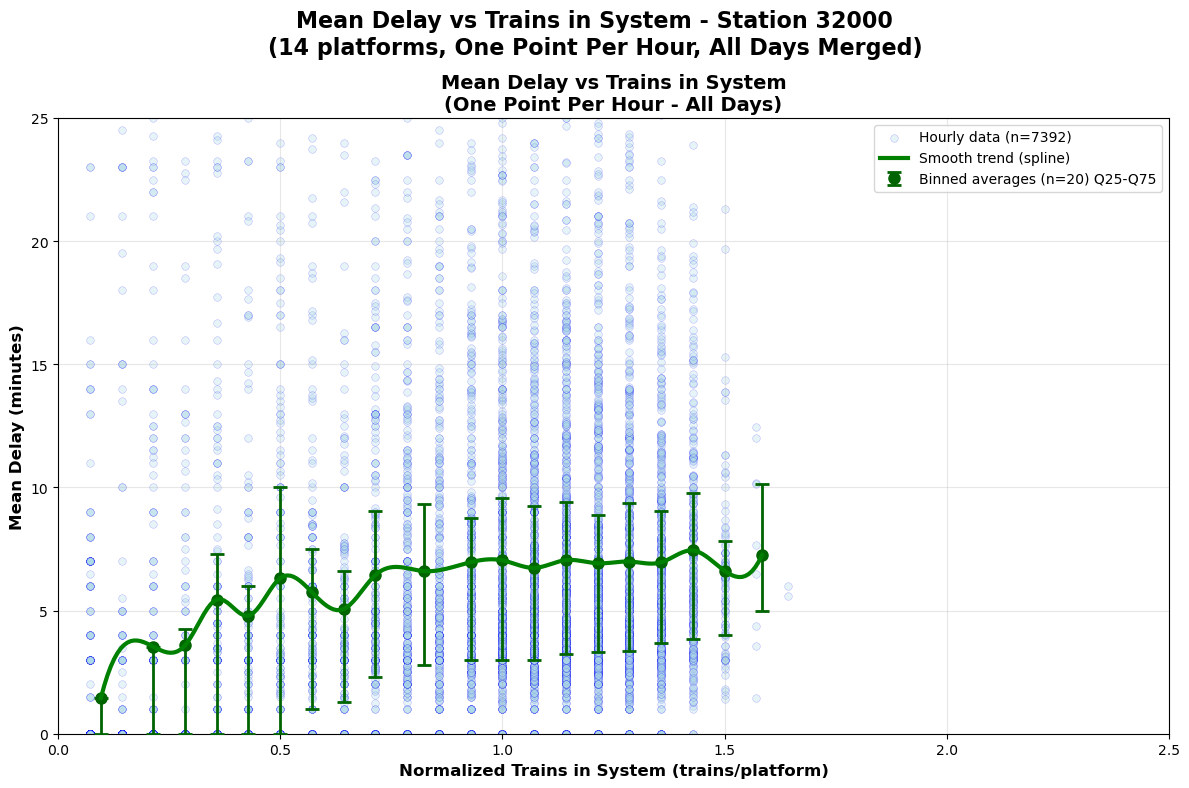

In [59]:
# Test trains in system vs delay analysis for Manchester Piccadilly
print("Running trains in system vs delay analysis...")
delay_results = plot_trains_in_system_vs_delay(
    station_id='32000',
    all_data=all_data,
    time_window_minutes=60,
    num_platforms=14,
    figsize=(18, 8),
    max_delay_percentile=98,
    dwell_time_minutes=5
)
plt.show()

Running trains in system vs delay analysis...
🚂 TRAINS IN SYSTEM vs DELAY ANALYSIS FOR STATION 33087
📊 Platforms: 5, Assumed Dwell Time: 5 min
📏 Trains in system NORMALIZED by 5 platforms
📏 ONE POINT PER HOUR (same as plot_variable_relationships)
⚠️  DELAY calculated ONLY from delayed trains (delay > 0)
Loaded 58498 total records for station 33087
Using 57734 arrived trains
Loaded 58498 total records for station 33087
Using 57734 arrived trains
Created 57734 valid timestamps
Created 57734 valid timestamps

✅ Processed 6441 hours total (weekdays and weekends merged)

📊 STATION 33087 - DELAY vs TRAINS IN SYSTEM (ALL DAYS)

DATA SUMMARY:
  - Total hours analyzed: 6441
  - Normalized trains in system range: 0.200 - 2.400 trains/platform
  - Mean delay range: 0.00 - 30.00 minutes
  - Overall mean delay: 6.15 minutes
  - Hours with delays > 0: 4069 (63.2%)
  - Correlation (trains in system vs delay): 0.164

✅ Processed 6441 hours total (weekdays and weekends merged)

📊 STATION 33087 - DELAY 

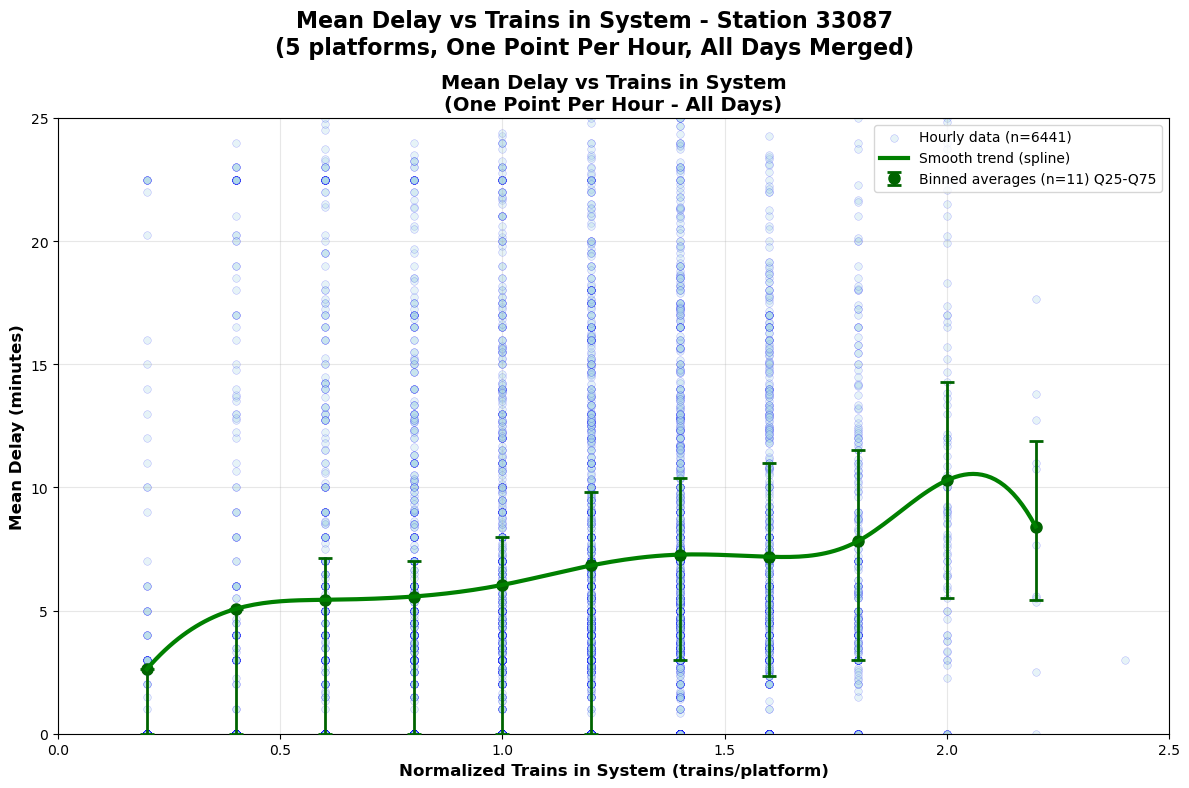

In [60]:
# Test trains in system vs delay analysis for Manchester Oxford Road
print("Running trains in system vs delay analysis...")
delay_results = plot_trains_in_system_vs_delay(
    station_id='33087',
    all_data=all_data,
    time_window_minutes=60,
    num_platforms=5,
    figsize=(18, 8),
    max_delay_percentile=98,
    dwell_time_minutes=5
)
plt.show()

Running trains in system vs delay analysis...
🚂 TRAINS IN SYSTEM vs DELAY ANALYSIS FOR STATION 70261
📊 Platforms: 6, Assumed Dwell Time: 5 min
📏 Trains in system NORMALIZED by 6 platforms
📏 ONE POINT PER HOUR (same as plot_variable_relationships)
⚠️  DELAY calculated ONLY from delayed trains (delay > 0)
Loaded 67183 total records for station 70261
Using 66786 arrived trains
Created 66786 valid timestamps

✅ Processed 6936 hours total (weekdays and weekends merged)

📊 STATION 70261 - DELAY vs TRAINS IN SYSTEM (ALL DAYS)

DATA SUMMARY:
  - Total hours analyzed: 6936
  - Normalized trains in system range: 0.167 - 1.667 trains/platform
  - Mean delay range: 0.00 - 15.71 minutes
  - Overall mean delay: 2.93 minutes
  - Hours with delays > 0: 4670 (67.3%)
  - Correlation (trains in system vs delay): 0.349


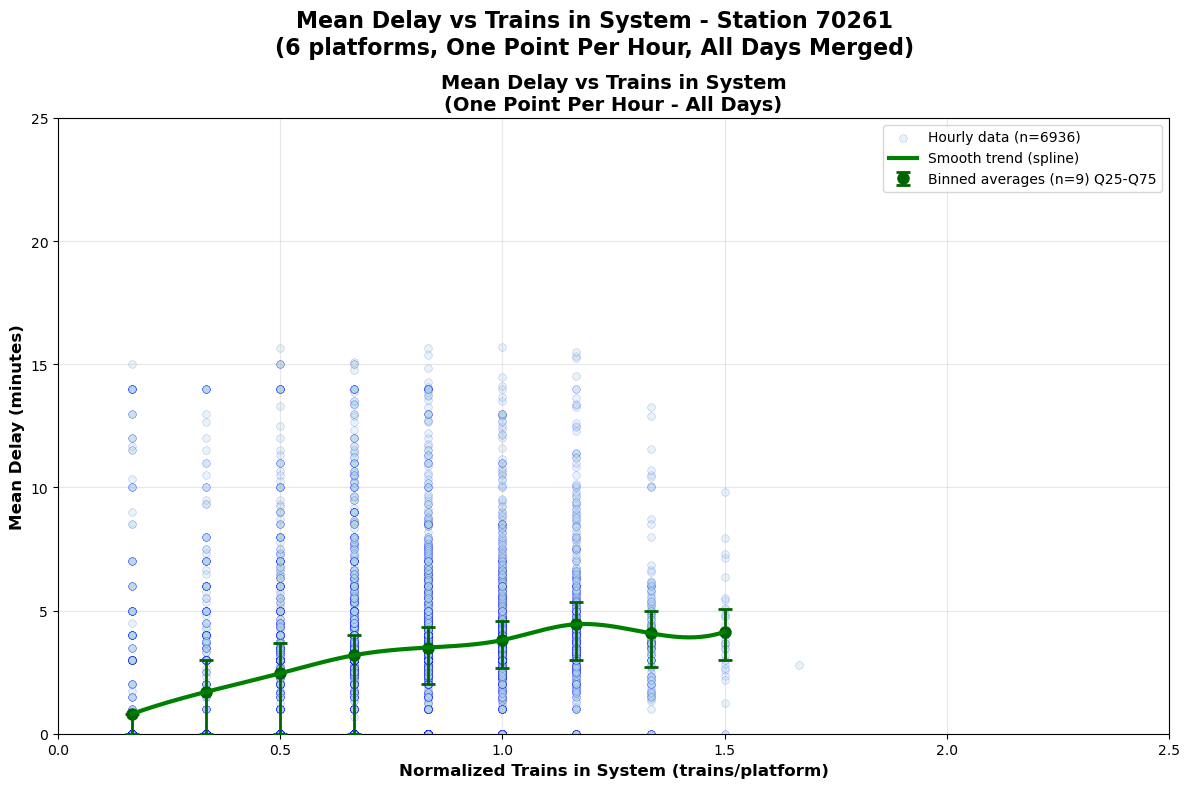

In [97]:
# Test trains in system vs delay analysis for Milton Keynes Central
print("Running trains in system vs delay analysis...")
delay_results = plot_trains_in_system_vs_delay(
    station_id='70261',
    all_data=all_data,
    time_window_minutes=60,
    num_platforms=6,
    figsize=(18, 8),
    max_delay_percentile=98,
    dwell_time_minutes=5
)
plt.show()

Running trains in system vs delay analysis...
🚂 TRAINS IN SYSTEM vs DELAY ANALYSIS FOR STATION 69202
📊 Platforms: 7, Assumed Dwell Time: 5 min
📏 Trains in system NORMALIZED by 7 platforms
📏 ONE POINT PER HOUR (same as plot_variable_relationships)
⚠️  DELAY calculated ONLY from delayed trains (delay > 0)
Loaded 82958 total records for station 69202
Using 82922 arrived trains
Created 82922 valid timestamps
Created 82922 valid timestamps

✅ Processed 6515 hours total (weekdays and weekends merged)

📊 STATION 69202 - DELAY vs TRAINS IN SYSTEM (ALL DAYS)

DATA SUMMARY:
  - Total hours analyzed: 6515
  - Normalized trains in system range: 0.143 - 1.286 trains/platform
  - Mean delay range: 0.00 - 17.67 minutes
  - Overall mean delay: 3.58 minutes
  - Hours with delays > 0: 4987 (76.5%)
  - Correlation (trains in system vs delay): 0.370

✅ Processed 6515 hours total (weekdays and weekends merged)

📊 STATION 69202 - DELAY vs TRAINS IN SYSTEM (ALL DAYS)

DATA SUMMARY:
  - Total hours analyzed: 

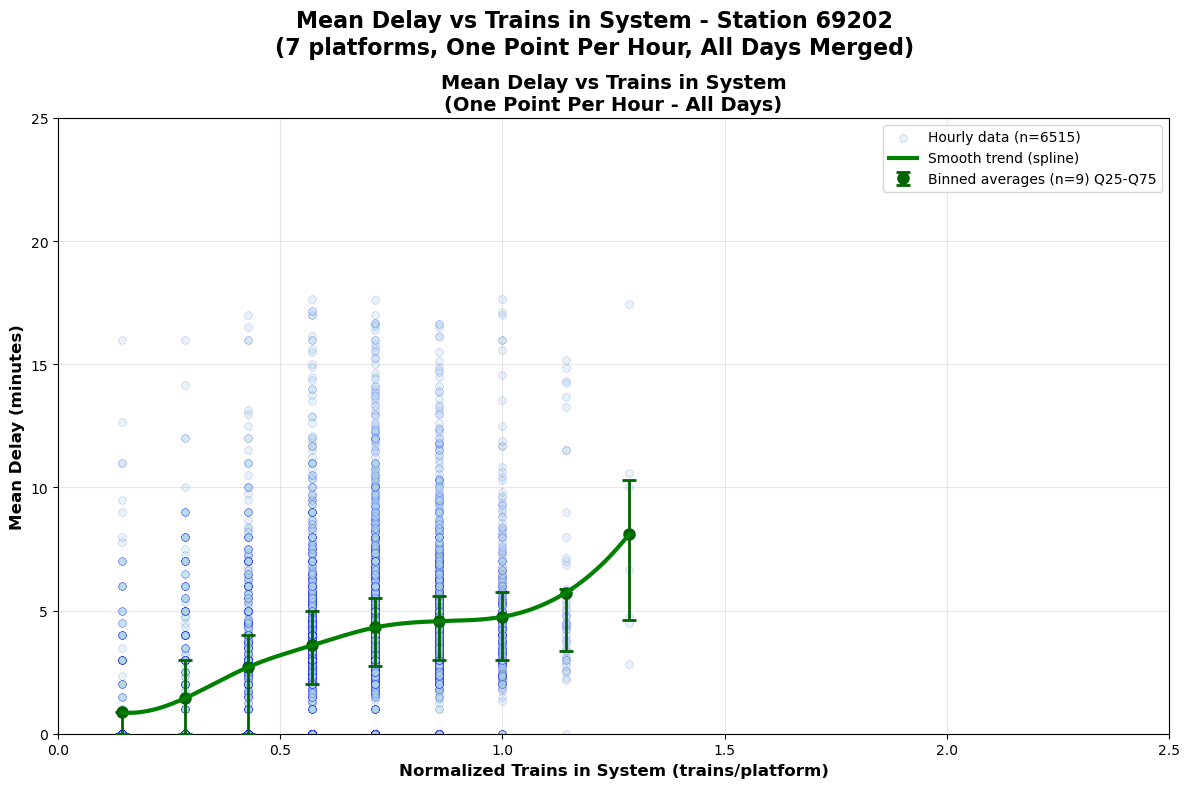

In [66]:
# Test trains in system vs delay analysis for Coventry
print("Running trains in system vs delay analysis...")
delay_results = plot_trains_in_system_vs_delay(
    station_id='69202',
    all_data=all_data,
    time_window_minutes=60,
    num_platforms=7,
    figsize=(18, 8),
    max_delay_percentile=98,
    dwell_time_minutes=5
)
plt.show()

Best performing stations

Running trains in system vs delay analysis...
🚂 TRAINS IN SYSTEM vs DELAY ANALYSIS FOR STATION 51531
📊 Platforms: 3, Assumed Dwell Time: 5 min
📏 Trains in system NORMALIZED by 3 platforms
📏 ONE POINT PER HOUR (same as plot_variable_relationships)
⚠️  DELAY calculated ONLY from delayed trains (delay > 0)
Loaded 28810 total records for station 51531
Using 28796 arrived trains
Created 28796 valid timestamps

✅ Processed 6249 hours total (weekdays and weekends merged)

📊 STATION 51531 - DELAY vs TRAINS IN SYSTEM (ALL DAYS)

DATA SUMMARY:
  - Total hours analyzed: 6249
  - Normalized trains in system range: 0.333 - 2.333 trains/platform
  - Mean delay range: 0.00 - 9.00 minutes
  - Overall mean delay: 1.32 minutes
  - Hours with delays > 0: 2383 (38.1%)
  - Correlation (trains in system vs delay): 0.236


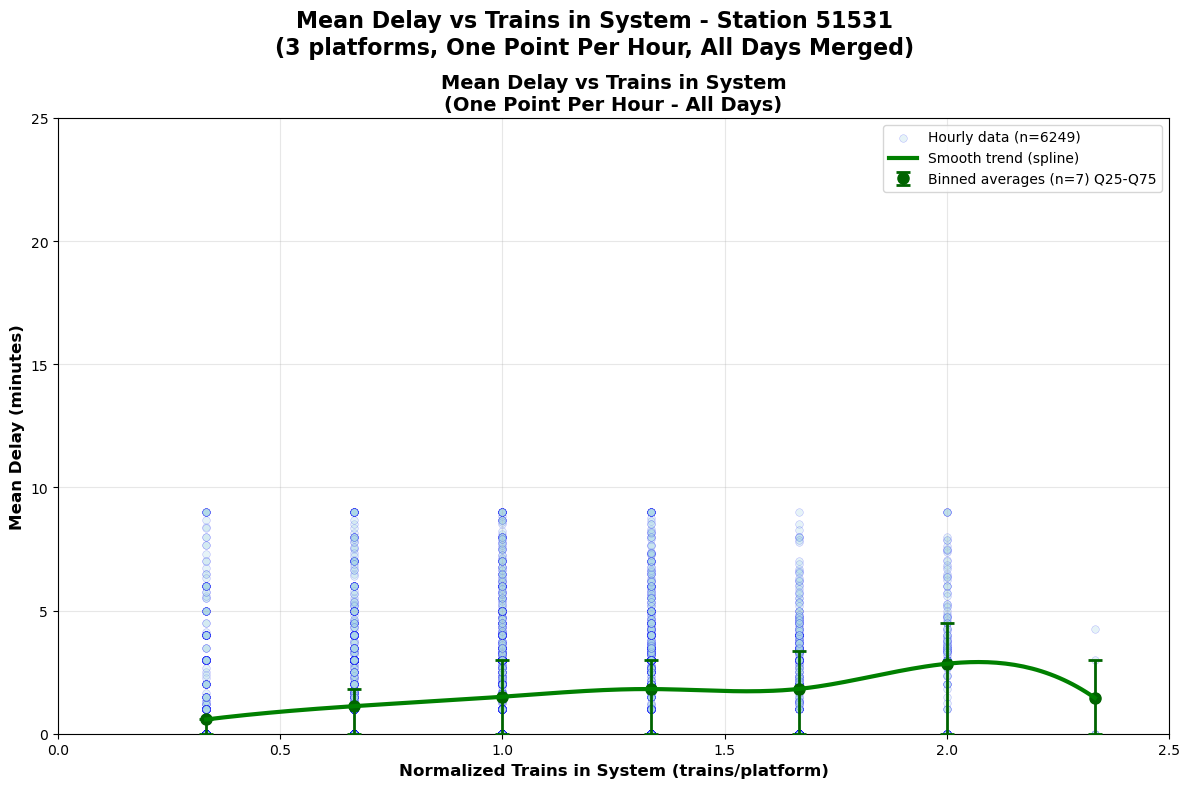

In [143]:
# Test trains in system vs delay analysis for Barking
print("Running trains in system vs delay analysis...")
delay_results = plot_trains_in_system_vs_delay(
    station_id='51531',
    all_data=all_data,
    time_window_minutes=60,
    num_platforms=3,
    figsize=(18, 8),
    max_delay_percentile=98,
    dwell_time_minutes=5
)
plt.show()

Running trains in system vs delay analysis...
🚂 TRAINS IN SYSTEM vs DELAY ANALYSIS FOR STATION 87222
📊 Platforms: 4, Assumed Dwell Time: 5 min
📏 Trains in system NORMALIZED by 4 platforms
📏 ONE POINT PER HOUR (same as plot_variable_relationships)
⚠️  DELAY calculated ONLY from delayed trains (delay > 0)
Loaded 28585 total records for station 87222
Using 28584 arrived trains
Created 28584 valid timestamps
Created 28584 valid timestamps

✅ Processed 6393 hours total (weekdays and weekends merged)

📊 STATION 87222 - DELAY vs TRAINS IN SYSTEM (ALL DAYS)

DATA SUMMARY:
  - Total hours analyzed: 6393
  - Normalized trains in system range: 0.250 - 2.500 trains/platform
  - Mean delay range: 0.00 - 10.00 minutes
  - Overall mean delay: 1.91 minutes
  - Hours with delays > 0: 3553 (55.6%)
  - Correlation (trains in system vs delay): 0.454

✅ Processed 6393 hours total (weekdays and weekends merged)

📊 STATION 87222 - DELAY vs TRAINS IN SYSTEM (ALL DAYS)

DATA SUMMARY:
  - Total hours analyzed: 

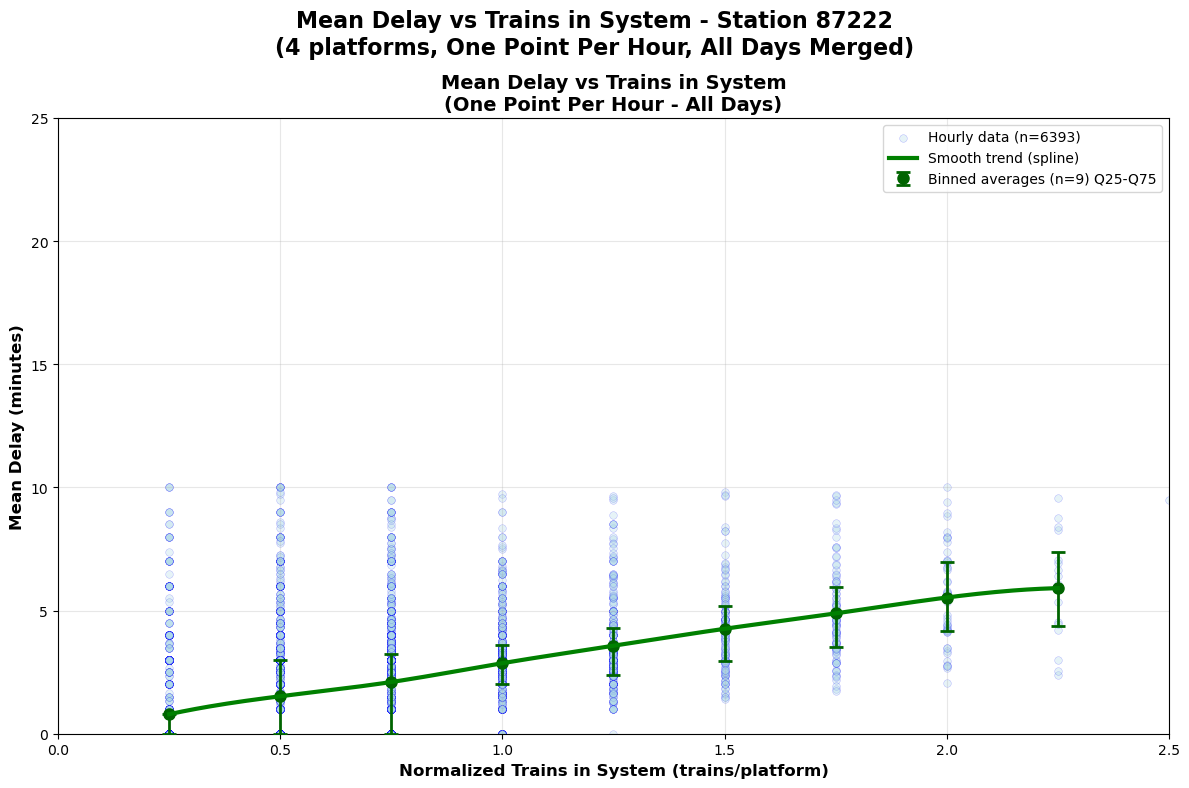

In [62]:
# Test trains in system vs delay analysis for Balham (4 NWR plt and 2 underground)
print("Running trains in system vs delay analysis...")
delay_results = plot_trains_in_system_vs_delay(
    station_id='87222',
    all_data=all_data,
    time_window_minutes=60,
    num_platforms=4,
    figsize=(18, 8),
    max_delay_percentile=98,
    dwell_time_minutes=5
)
plt.show()

Running trains in system vs delay analysis...
🚂 TRAINS IN SYSTEM vs DELAY ANALYSIS FOR STATION 88403
📊 Platforms: 7, Assumed Dwell Time: 5 min
📏 Trains in system NORMALIZED by 7 platforms
📏 ONE POINT PER HOUR (same as plot_variable_relationships)
⚠️  DELAY calculated ONLY from delayed trains (delay > 0)
Loaded 20149 total records for station 88403
Using 19718 arrived trains
Created 19718 valid timestamps
Created 19718 valid timestamps

✅ Processed 5210 hours total (weekdays and weekends merged)

📊 STATION 88403 - DELAY vs TRAINS IN SYSTEM (ALL DAYS)

DATA SUMMARY:
  - Total hours analyzed: 5210
  - Normalized trains in system range: 0.143 - 1.857 trains/platform
  - Mean delay range: 0.00 - 59.00 minutes
  - Overall mean delay: 2.00 minutes
  - Hours with delays > 0: 1859 (35.7%)
  - Correlation (trains in system vs delay): 0.287

✅ Processed 5210 hours total (weekdays and weekends merged)

📊 STATION 88403 - DELAY vs TRAINS IN SYSTEM (ALL DAYS)

DATA SUMMARY:
  - Total hours analyzed: 

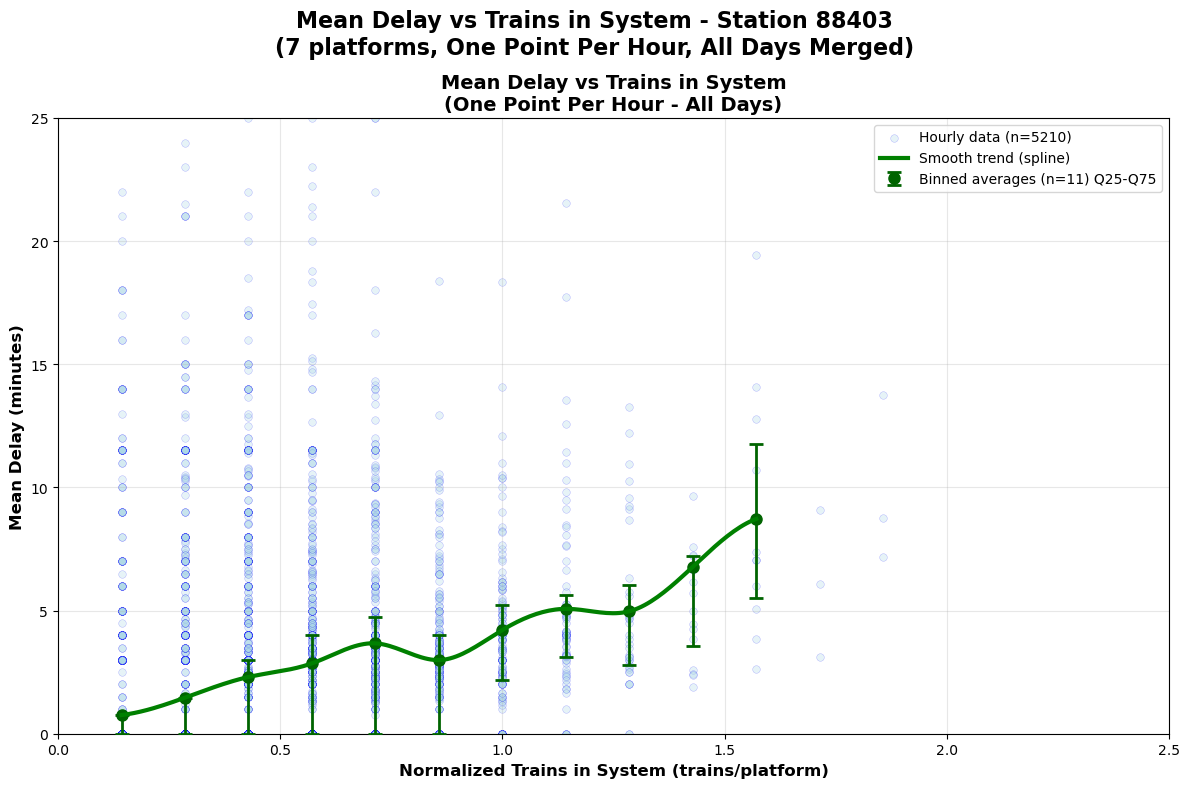

In [73]:
# Test trains in system vs delay analysis for London Cannon Street
print("Running trains in system vs delay analysis...")
delay_results = plot_trains_in_system_vs_delay(
    station_id='88403',
    all_data=all_data,
    time_window_minutes=60,
    num_platforms=7,
    figsize=(18, 8),
    max_delay_percentile=100,
    dwell_time_minutes=5
)
plt.show()

Running trains in system vs delay analysis...
🚂 TRAINS IN SYSTEM vs DELAY ANALYSIS FOR STATION 63021
📊 Platforms: 6, Assumed Dwell Time: 5 min
📏 Trains in system NORMALIZED by 6 platforms
📏 ONE POINT PER HOUR (same as plot_variable_relationships)
⚠️  DELAY calculated ONLY from delayed trains (delay > 0)
Loaded 30663 total records for station 63021
Using 30061 arrived trains
Created 30061 valid timestamps
Created 30061 valid timestamps

✅ Processed 5791 hours total (weekdays and weekends merged)

📊 STATION 63021 - DELAY vs TRAINS IN SYSTEM (ALL DAYS)

DATA SUMMARY:
  - Total hours analyzed: 5791
  - Normalized trains in system range: 0.167 - 0.833 trains/platform
  - Mean delay range: 0.00 - 96.00 minutes
  - Overall mean delay: 2.13 minutes
  - Hours with delays > 0: 2320 (40.1%)
  - Correlation (trains in system vs delay): 0.140

✅ Processed 5791 hours total (weekdays and weekends merged)

📊 STATION 63021 - DELAY vs TRAINS IN SYSTEM (ALL DAYS)

DATA SUMMARY:
  - Total hours analyzed: 

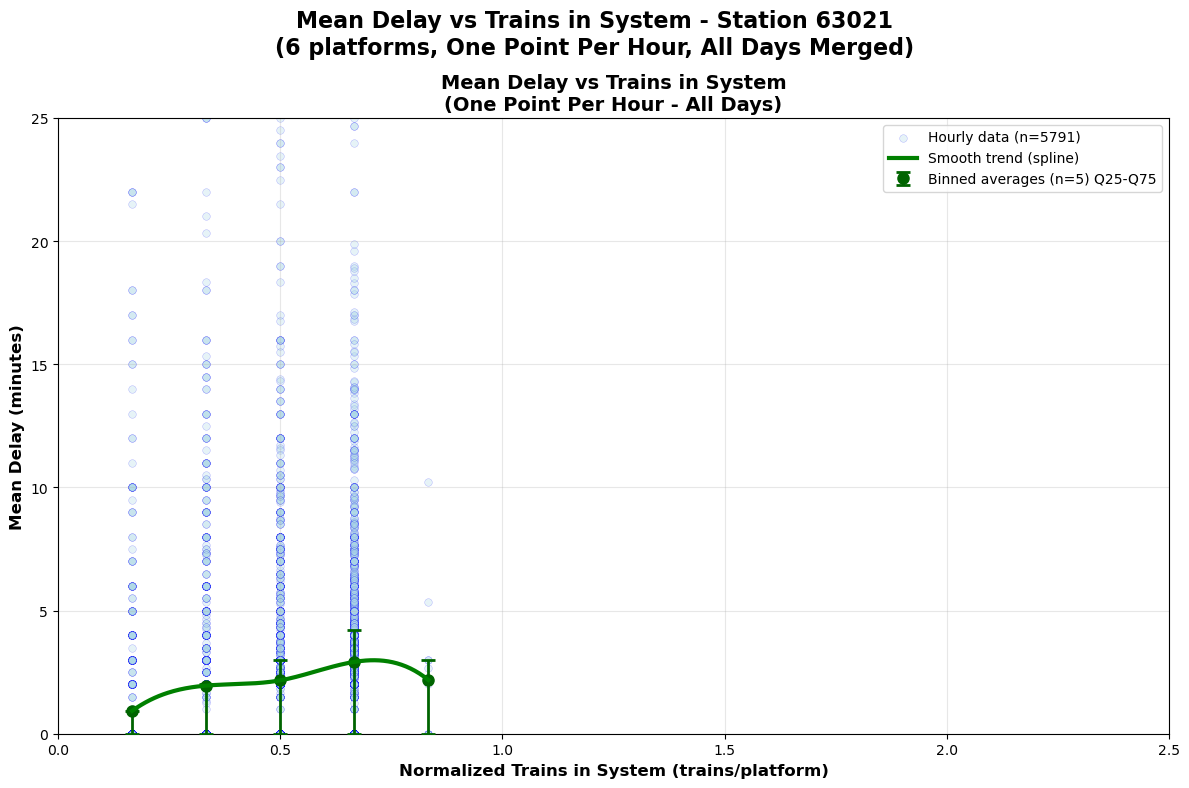

In [72]:
# Test trains in system vs delay analysis for Marylebone London
print("Running trains in system vs delay analysis...")
delay_results = plot_trains_in_system_vs_delay(
    station_id='63021',
    all_data=all_data,
    time_window_minutes=60,
    num_platforms=6,
    figsize=(18, 8),
    max_delay_percentile=100,
    dwell_time_minutes=5
)
plt.show()

For 'best' stations

🔍 EXPLORING DELAY OUTLIERS FOR STATION 51531
📊 Focus: Extreme delays and worst-case scenarios
✅ Processed 6347 hours with delay statistics
✅ Processed 6347 hours with delay statistics


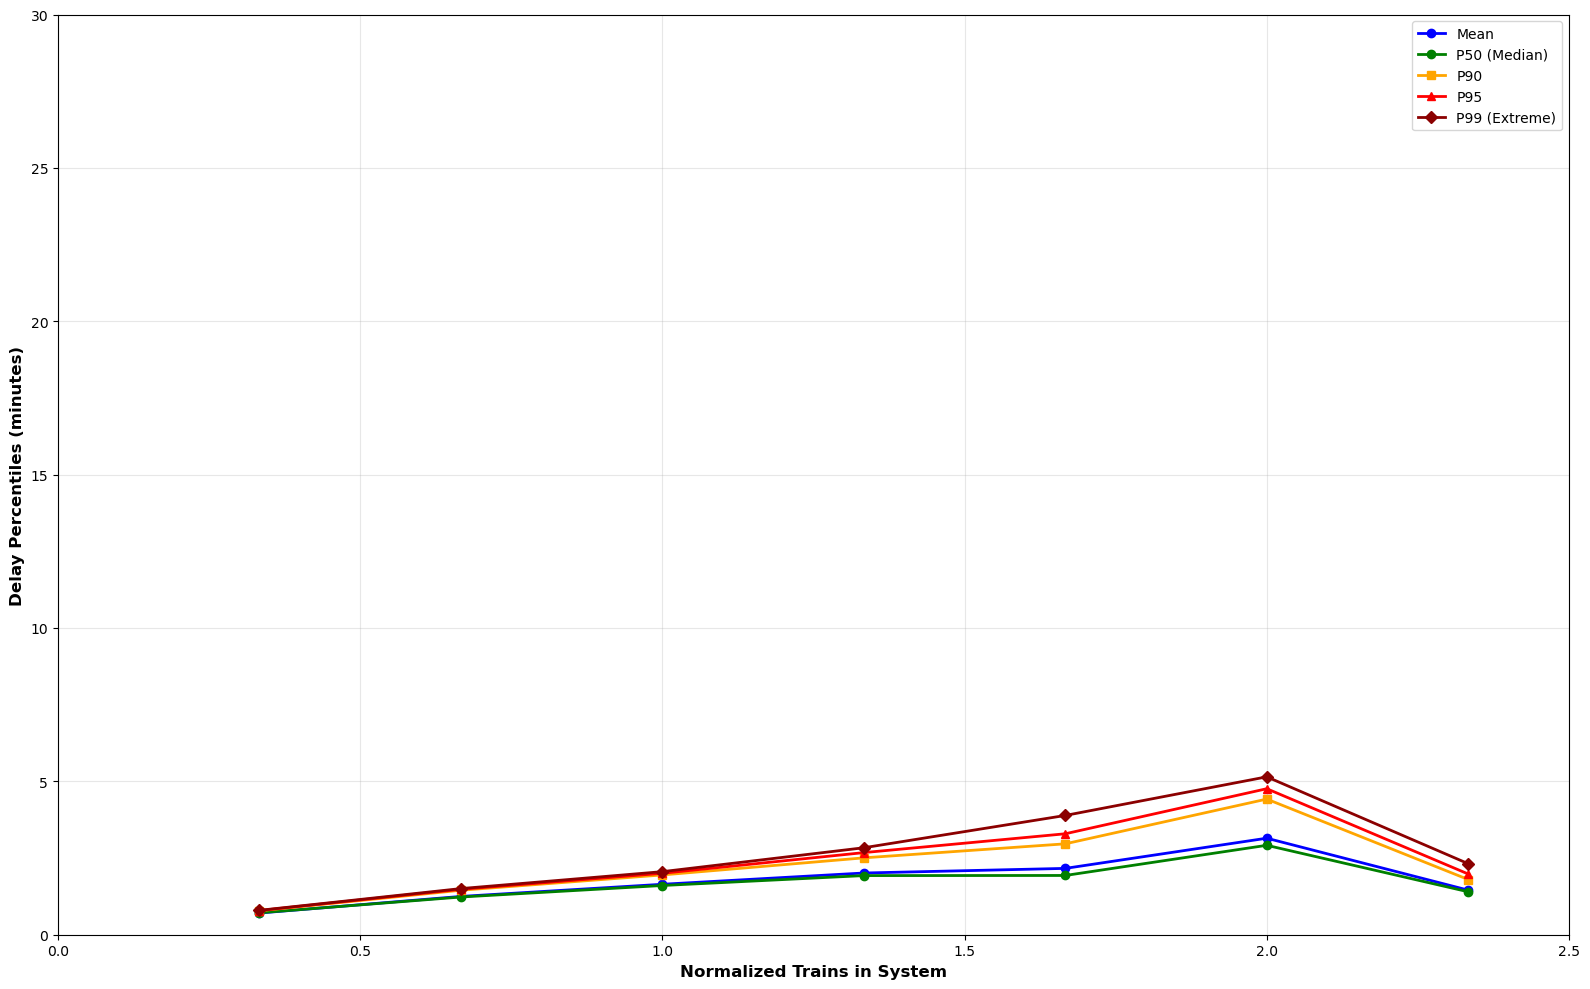


📈 EXTREME DELAY STATISTICS - STATION 51531

🔴 TOP 5 WORST HOURS (by maximum delay):
  2024-04-15 19:00: Max=150.0min, Mean=15.8min, Trains=1.67/platform (36 delayed)
  2024-04-15 20:00: Max=150.0min, Mean=19.6min, Trains=1.67/platform (17 delayed)
  2024-04-15 21:00: Max=150.0min, Mean=36.8min, Trains=1.67/platform (8 delayed)
  2024-04-15 22:00: Max=150.0min, Mean=32.0min, Trains=1.33/platform (10 delayed)
  2024-06-28 21:00: Max=45.0min, Mean=13.6min, Trains=1.67/platform (18 delayed)

📊 OVERALL DELAY STATISTICS:
  - P90 delay across all hours: 1.81 min
  - P95 delay across all hours: 1.90 min
  - P99 delay across all hours: 2.00 min
  - Maximum single delay: 150.00 min
  - Hours with delays > 30 min: 17 (0.3%)

🔍 HIGH LOAD ANALYSIS (>1.0 trains/platform):
  - Hours in high load: 1752 (27.6%)
  - Mean delay in high load: 2.16 min
  - P95 delay in high load: 3.04 min


In [113]:
# Run the outlier analysis for Barking (9 plts, 3 only for NWR)
outlier_stats_32000 = explore_delay_outliers(
    station_id='51531',
    all_data=all_data,
    num_platforms=3,
    dwell_time_minutes=5,
    figsize=(16, 10)
)

🔍 EXPLORING DELAY OUTLIERS FOR STATION 63021
📊 Focus: Extreme delays and worst-case scenarios
✅ Processed 5791 hours with delay statistics
✅ Processed 5791 hours with delay statistics


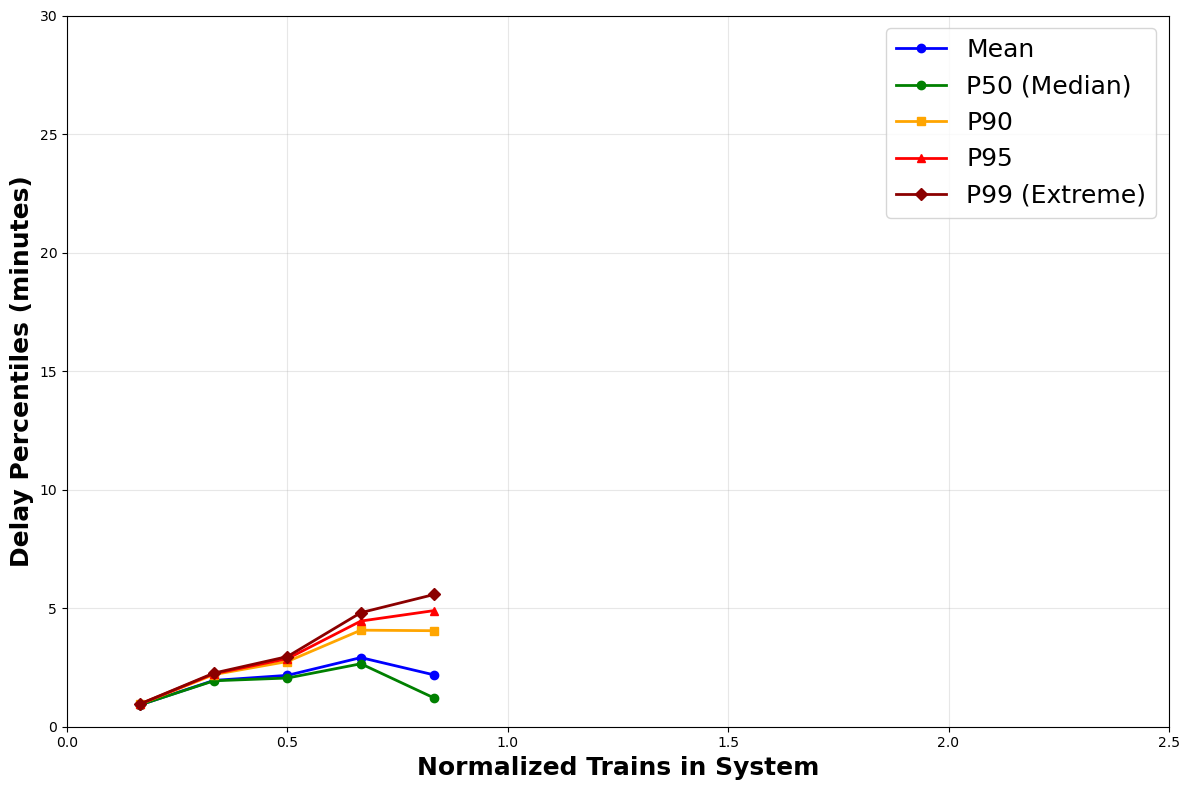


📈 EXTREME DELAY STATISTICS - STATION 63021

🔴 TOP 5 WORST HOURS (by maximum delay):
  2024-03-25 20:00: Max=122.0min, Mean=15.5min, Trains=0.67/platform (13 delayed)
  2024-03-25 21:00: Max=122.0min, Mean=19.6min, Trains=0.67/platform (10 delayed)
  2024-03-25 22:00: Max=122.0min, Mean=39.7min, Trains=0.50/platform (6 delayed)
  2024-09-19 09:00: Max=112.0min, Mean=40.8min, Trains=0.67/platform (4 delayed)
  2024-09-19 10:00: Max=112.0min, Mean=24.7min, Trains=0.67/platform (6 delayed)

📊 OVERALL DELAY STATISTICS:
  - P90 delay across all hours: 2.72 min
  - P95 delay across all hours: 2.89 min
  - P99 delay across all hours: 3.03 min
  - Maximum single delay: 122.00 min
  - Hours with delays > 30 min: 61 (1.1%)


In [107]:
# Run the outlier analysis for Marylebone (6 for NWR, 2 London Underground)
outlier_stats = explore_delay_outliers(
    station_id='63021',
    all_data=all_data,
    num_platforms=6,
    dwell_time_minutes=5,
    figsize=(16, 10)
)

🔍 EXPLORING DELAY OUTLIERS FOR STATION 88403
📊 Focus: Extreme delays and worst-case scenarios
✅ Processed 5210 hours with delay statistics
✅ Processed 5210 hours with delay statistics


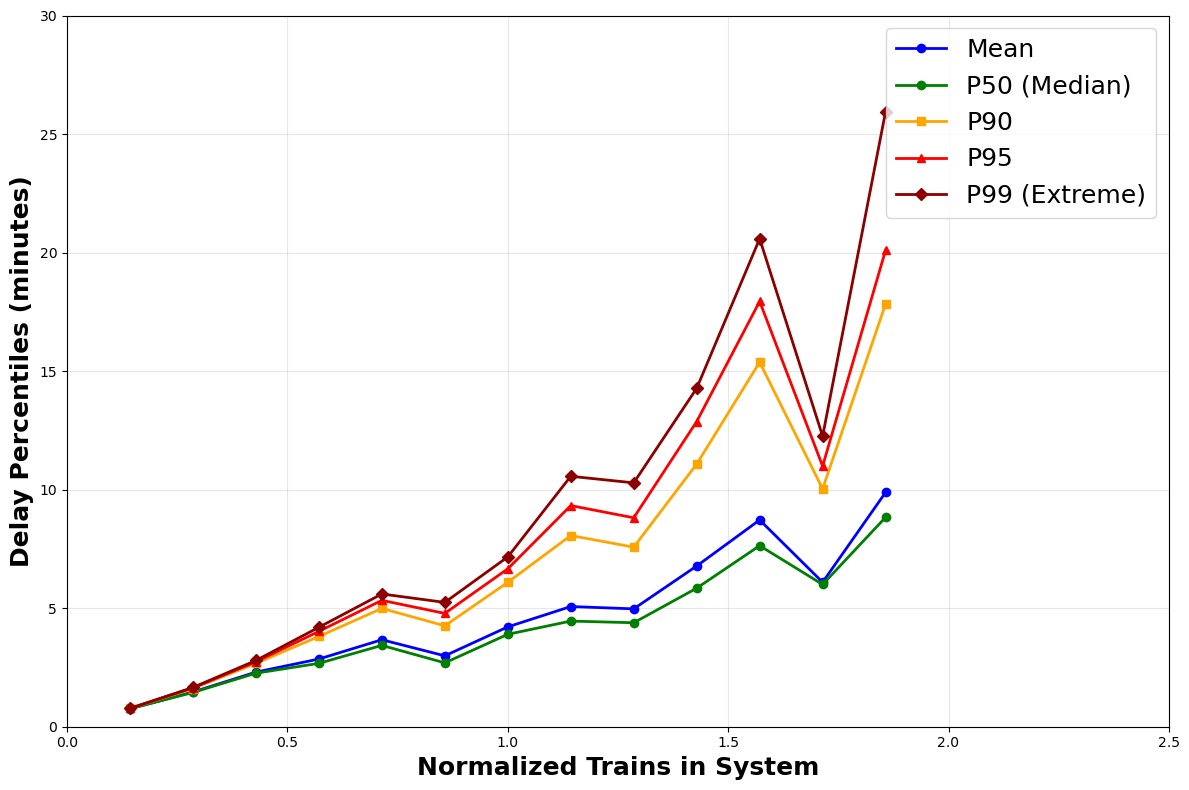


📈 EXTREME DELAY STATISTICS - STATION 88403

🔴 TOP 5 WORST HOURS (by maximum delay):
  2024-02-27 20:00: Max=74.0min, Mean=22.2min, Trains=0.57/platform (8 delayed)
  2024-02-27 21:00: Max=74.0min, Mean=18.8min, Trains=0.57/platform (9 delayed)
  2024-02-27 22:00: Max=74.0min, Mean=21.4min, Trains=0.57/platform (5 delayed)
  2024-10-31 09:00: Max=69.0min, Mean=31.4min, Trains=1.43/platform (9 delayed)
  2024-10-31 10:00: Max=69.0min, Mean=37.0min, Trains=0.71/platform (8 delayed)

📊 OVERALL DELAY STATISTICS:
  - P90 delay across all hours: 2.52 min
  - P95 delay across all hours: 2.67 min
  - P99 delay across all hours: 2.80 min
  - Maximum single delay: 74.00 min
  - Hours with delays > 30 min: 47 (0.9%)

🔍 HIGH LOAD ANALYSIS (>1.0 trains/platform):
  - Hours in high load: 142 (2.7%)
  - Mean delay in high load: 5.64 min
  - P95 delay in high load: 10.53 min

🔴 TOP 5 WORST HOURS (by maximum delay):
  2024-02-27 20:00: Max=74.0min, Mean=22.2min, Trains=0.57/platform (8 delayed)
  2024-

In [108]:
# Run the outlier analysis for London Cannon Street (9 total, 7 NWR)
outlier_stats_32000 = explore_delay_outliers(
    station_id='88403',
    all_data=all_data,
    num_platforms=7,
    dwell_time_minutes=5,
    figsize=(16, 10)
)

For 'worst' station

🔍 EXPLORING DELAY OUTLIERS FOR STATION 32000
📊 Focus: Extreme delays and worst-case scenarios
✅ Processed 7514 hours with delay statistics
✅ Processed 7514 hours with delay statistics


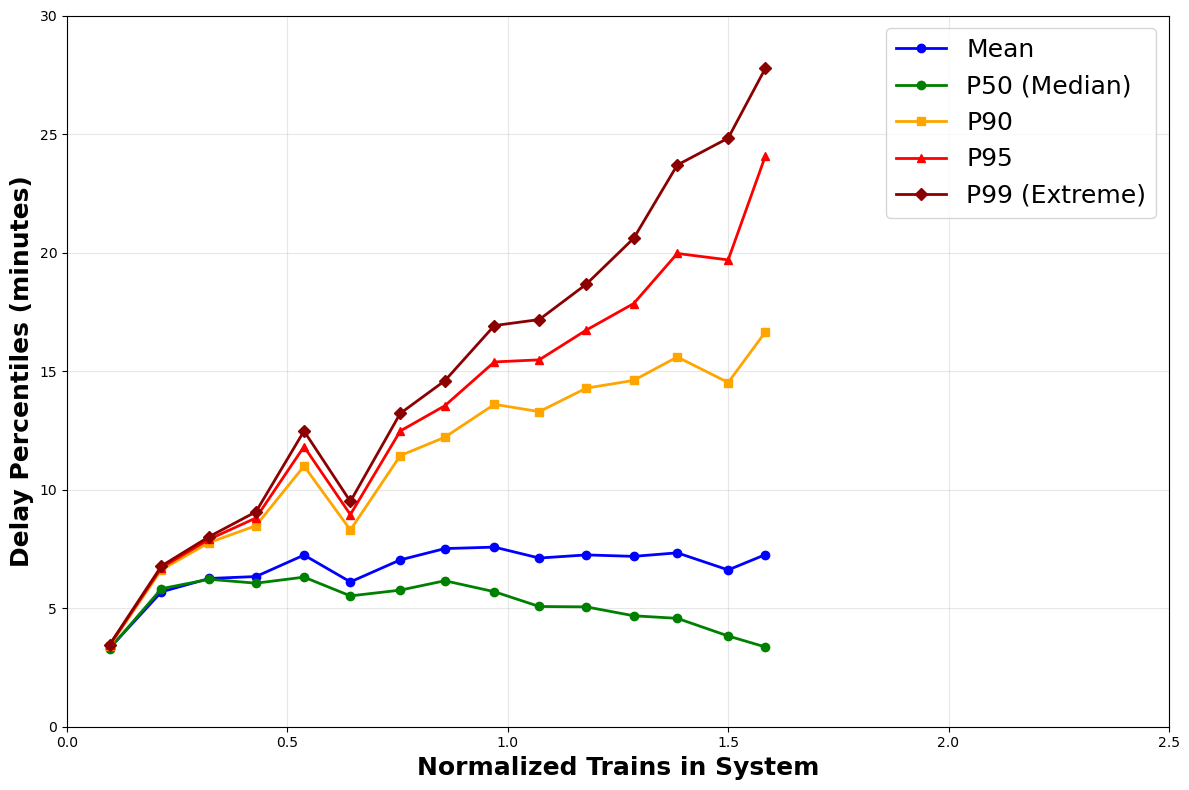


📈 EXTREME DELAY STATISTICS - STATION 32000

🔴 TOP 5 WORST HOURS (by maximum delay):
  2024-11-02 21:00: Max=279.0min, Mean=25.2min, Trains=1.36/platform (35 delayed)
  2024-11-02 22:00: Max=279.0min, Mean=34.0min, Trains=1.29/platform (19 delayed)
  2024-11-02 23:00: Max=279.0min, Mean=62.2min, Trains=0.57/platform (8 delayed)
  2024-11-03 00:00: Max=279.0min, Mean=84.2min, Trains=0.50/platform (6 delayed)
  2024-11-03 01:00: Max=279.0min, Mean=279.0min, Trains=0.07/platform (1 delayed)

📊 OVERALL DELAY STATISTICS:
  - P90 delay across all hours: 12.00 min
  - P95 delay across all hours: 13.91 min
  - P99 delay across all hours: 15.49 min
  - Maximum single delay: 279.00 min
  - Hours with delays > 30 min: 1260 (16.8%)

🔍 HIGH LOAD ANALYSIS (>1.0 trains/platform):
  - Hours in high load: 3559 (47.4%)
  - Mean delay in high load: 7.22 min
  - P95 delay in high load: 17.53 min


In [109]:
# Run the outlier analysis for Manchester Piccadilly
outlier_stats_32000 = explore_delay_outliers(
    station_id='32000',
    all_data=all_data,
    num_platforms=14,
    dwell_time_minutes=5,
    figsize=(16, 10)
)

🔍 EXPLORING DELAY OUTLIERS FOR STATION 33087
📊 Focus: Extreme delays and worst-case scenarios
✅ Processed 6561 hours with delay statistics
✅ Processed 6561 hours with delay statistics


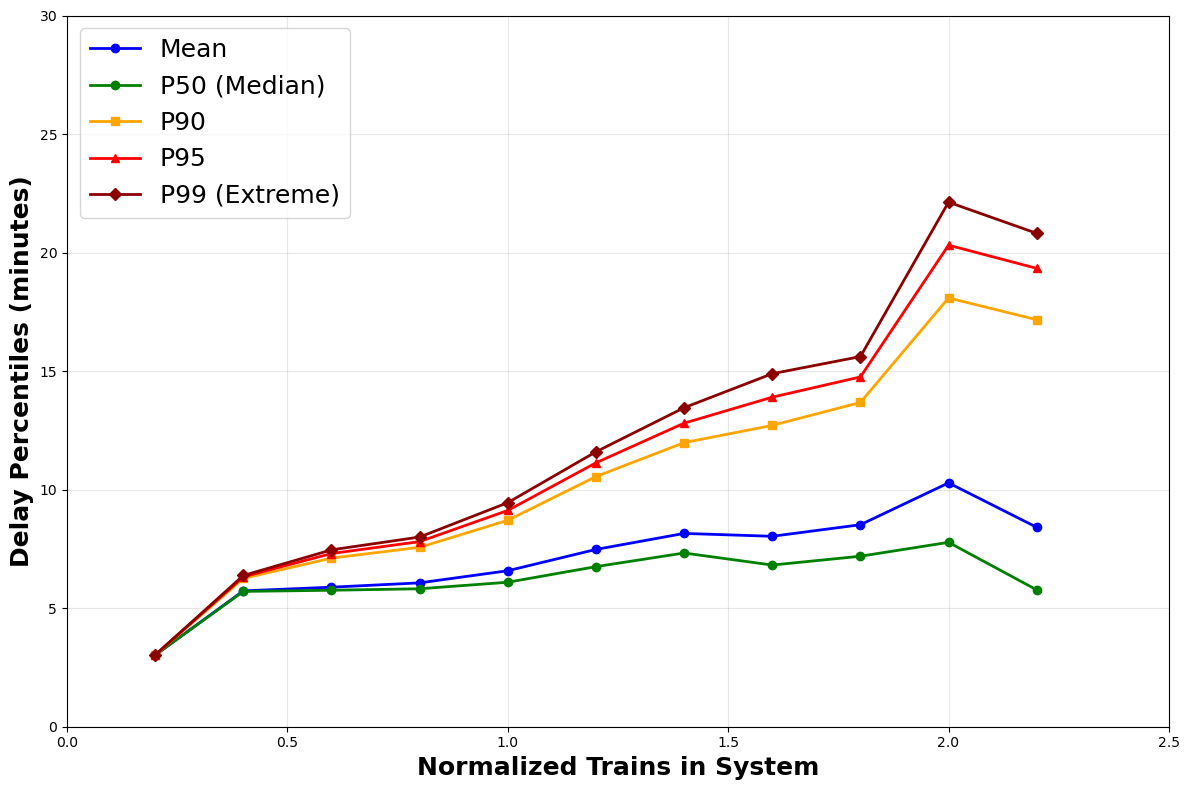


📈 EXTREME DELAY STATISTICS - STATION 33087

🔴 TOP 5 WORST HOURS (by maximum delay):
  2024-08-09 22:00: Max=132.0min, Mean=43.2min, Trains=1.20/platform (10 delayed)
  2024-08-09 23:00: Max=132.0min, Mean=52.3min, Trains=1.00/platform (5 delayed)
  2024-08-10 00:00: Max=132.0min, Mean=55.1min, Trains=0.60/platform (4 delayed)
  2024-08-10 01:00: Max=132.0min, Mean=84.0min, Trains=0.40/platform (2 delayed)
  2024-05-03 18:00: Max=127.0min, Mean=20.6min, Trains=1.60/platform (8 delayed)

📊 OVERALL DELAY STATISTICS:
  - P90 delay across all hours: 9.35 min
  - P95 delay across all hours: 9.88 min
  - P99 delay across all hours: 10.32 min
  - Maximum single delay: 132.00 min
  - Hours with delays > 30 min: 441 (6.7%)

🔍 HIGH LOAD ANALYSIS (>1.0 trains/platform):
  - Hours in high load: 3172 (48.3%)
  - Mean delay in high load: 7.96 min
  - P95 delay in high load: 12.76 min


In [110]:
# Run the outlier analysis for Manchester Oxford Road
outlier_stats_32000 = explore_delay_outliers(
    station_id='33087',
    all_data=all_data,
    num_platforms=5,
    dwell_time_minutes=5,
    figsize=(16, 10)
)

🔍 EXPLORING DELAY OUTLIERS FOR STATION 70261
📊 Focus: Extreme delays and worst-case scenarios
✅ Processed 7078 hours with delay statistics
✅ Processed 7078 hours with delay statistics


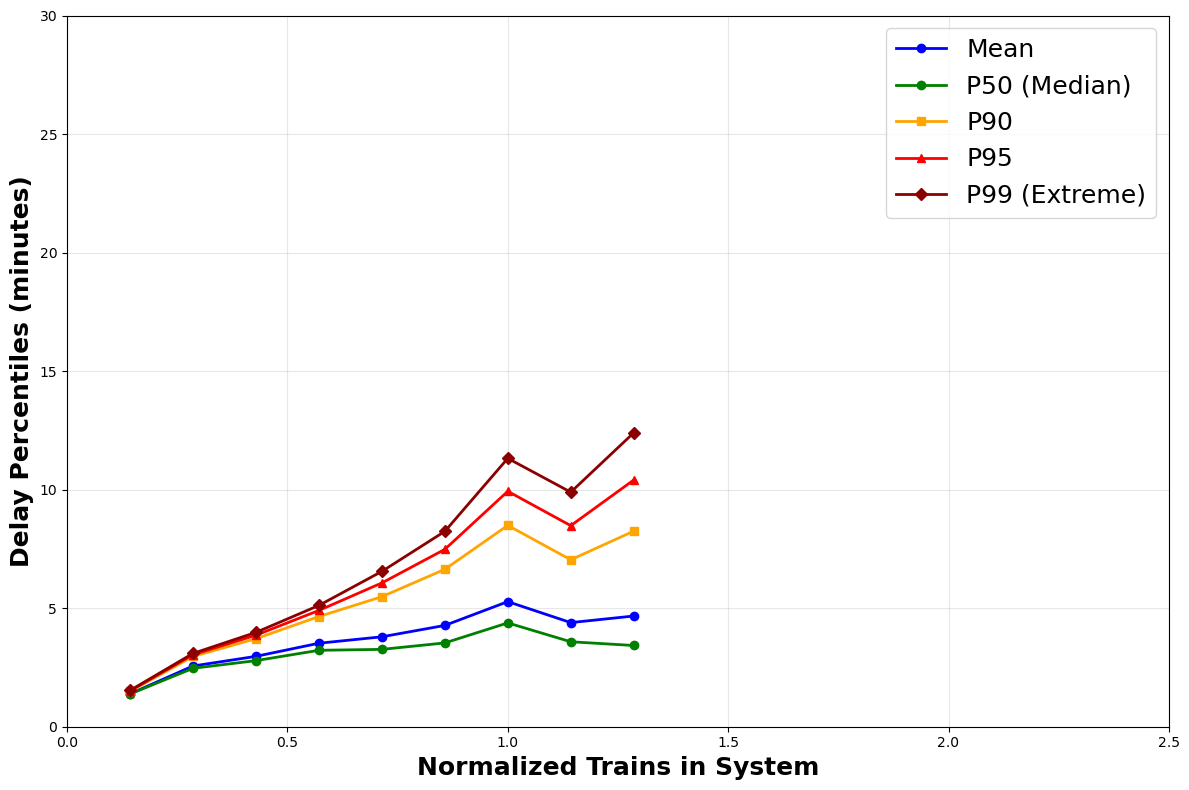


📈 EXTREME DELAY STATISTICS - STATION 70261

🔴 TOP 5 WORST HOURS (by maximum delay):
  2024-05-31 22:00: Max=140.0min, Mean=82.4min, Trains=1.00/platform (7 delayed)
  2024-05-31 23:00: Max=140.0min, Mean=63.0min, Trains=1.00/platform (10 delayed)
  2024-06-01 00:00: Max=140.0min, Mean=54.3min, Trains=0.86/platform (11 delayed)
  2024-06-01 01:00: Max=140.0min, Mean=140.0min, Trains=0.14/platform (1 delayed)
  2024-06-05 08:00: Max=115.0min, Mean=25.1min, Trains=0.86/platform (7 delayed)

📊 OVERALL DELAY STATISTICS:
  - P90 delay across all hours: 4.80 min
  - P95 delay across all hours: 5.27 min
  - P99 delay across all hours: 5.69 min
  - Maximum single delay: 140.00 min
  - Hours with delays > 30 min: 238 (3.4%)

🔍 HIGH LOAD ANALYSIS (>1.0 trains/platform):
  - Hours in high load: 185 (2.6%)
  - Mean delay in high load: 4.43 min
  - P95 delay in high load: 8.82 min


In [111]:
# Run the outlier analysis for Milton Keynes Central
outlier_stats_32000 = explore_delay_outliers(
    station_id='70261',
    all_data=all_data,
    num_platforms=7,
    dwell_time_minutes=5,
    figsize=(16, 10)
)

Why call it "System Load Level"?

 - It's the same "normalized trains in system" (trains per platform) in all panels, it's just a more descriptive label for the binned/categorical version.

- "System Load Level" suggests discrete categories (Low, Medium, High, etc.) rather than a continuous scale.

- It makes the boxplot easier to interpret for readers.

Percentiles tell you what percentage of delayed trains had delays below a certain value. For example:

- P50 (Median): 50% of delayed trains had delays below this value

- If P50 = 5 minutes, half of all delayed trains had delays ≤ 5 minutes

In [166]:
def plot_ontime_performance_vs_load(station_id, all_data, num_platforms=6, dwell_time_minutes=5, figsize=(12, 8)):
    """
    Visualize on-time performance (percentage of trains with PFPI_MINUTES = 0.0) 
    versus normalized trains in system (trains per platform).
    
    Parameters:
    -----------
    station_id : str
        The STANOX code for the station
    all_data : pd.DataFrame
        The complete dataset with all station data
    num_platforms : int
        Number of platforms at the station (for normalization)
    dwell_time_minutes : int
        Typical dwell time at the station in minutes
    figsize : tuple
        Figure size (width, height)
    
    Returns:
    --------
    pd.DataFrame
        Hourly statistics including on-time percentage and system load
    """
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    
    print(f"🎯 ON-TIME PERFORMANCE ANALYSIS FOR STATION {station_id}")
    print(f"📊 Focus: On-time trains (PFPI_MINUTES = 0.0 or NaN) vs System Load")
    print("=" * 70)
    
    # Filter and prepare data
    data = all_data[all_data['STANOX'] == str(station_id)].copy()
    if len(data) == 0:
        print(f"No data found for station {station_id}")
        return None
    
    all_arrived_data = data[data['EVENT_TYPE'] != 'C'].copy()
    if len(all_arrived_data) == 0:
        print("No arrived trains found.")
        return None
    
    # Convert PFPI_MINUTES to numeric, keeping NaN as NaN
    all_arrived_data['delay_minutes'] = pd.to_numeric(all_arrived_data['PFPI_MINUTES'], errors='coerce')
    
    # For time_in_system calculation, treat NaN as 0 (on-time)
    all_arrived_data['time_in_system'] = dwell_time_minutes + all_arrived_data['delay_minutes'].fillna(0)
    
    # Parse datetime
    def parse_event_datetime(event_dt_str):
        if pd.isna(event_dt_str):
            return None
        try:
            dt = pd.to_datetime(event_dt_str, format='%d-%b-%Y %H:%M', errors='coerce')
            return dt.date() if pd.notna(dt) else None
        except:
            return None
    
    all_arrived_data['event_date'] = all_arrived_data['EVENT_DATETIME'].apply(parse_event_datetime)
    
    # Build day-to-date mapping
    day_to_weekday = {'MO': 0, 'TU': 1, 'WE': 2, 'TH': 3, 'FR': 4, 'SA': 5, 'SU': 6}
    day_date_mapping = {}
    for day_code in day_to_weekday.keys():
        day_data = all_arrived_data[all_arrived_data['DAY'] == day_code]
        observed_dates = day_data['event_date'].dropna().unique()
        if len(observed_dates) > 0:
            day_date_mapping[day_code] = sorted(observed_dates)
    
    all_arrived_data['row_idx'] = range(len(all_arrived_data))
    
    def create_datetime_with_event_dates(row):
        try:
            day_code = row['DAY']
            time_val = row['ACTUAL_CALLS'] if pd.notna(row['ACTUAL_CALLS']) else row['PLANNED_CALLS']
            
            if pd.isna(time_val) or day_code not in day_to_weekday:
                return None
            
            time_str = str(int(time_val)).zfill(4)
            hour = int(time_str[:2])
            minute = int(time_str[2:])
            
            if pd.notna(row['event_date']):
                date_obj = row['event_date']
            else:
                if day_code in day_date_mapping and len(day_date_mapping[day_code]) > 0:
                    date_idx = (hash(str(row['TRAIN_SERVICE_CODE'])) + row['row_idx']) % len(day_date_mapping[day_code])
                    date_obj = day_date_mapping[day_code][date_idx]
                else:
                    return None
            
            dt = pd.Timestamp(year=date_obj.year, month=date_obj.month, 
                            day=date_obj.day, hour=hour, minute=minute)
            return dt
        except:
            return None
    
    all_arrived_data['arrival_time'] = all_arrived_data.apply(create_datetime_with_event_dates, axis=1)
    all_arrived_data['departure_time'] = all_arrived_data['arrival_time'] + pd.to_timedelta(
        all_arrived_data['time_in_system'], unit='min'
    )
    
    valid_data = all_arrived_data.dropna(subset=['arrival_time', 'departure_time']).copy()
    
    if len(valid_data) == 0:
        print("No valid datetime data.")
        return None
    
    # Calculate hourly statistics
    min_time = valid_data['arrival_time'].min().floor('h')
    max_time = valid_data['departure_time'].max().ceil('h')
    hourly_bins = pd.date_range(start=min_time, end=max_time, freq='h')
    
    hourly_stats_list = []
    
    for hour_start in hourly_bins[:-1]:
        hour_end = hour_start + pd.Timedelta(hours=1)
        
        in_system = valid_data[
            (valid_data['arrival_time'] < hour_end) & 
            (valid_data['departure_time'] > hour_start)
        ]
        trains_in_system = in_system['TRAIN_SERVICE_CODE'].nunique()
        trains_in_system_normalized = trains_in_system / num_platforms
        
        # Calculate on-time trains normalized (trains per platform per hour)
        # On-time = PFPI_MINUTES = 0.0 OR PFPI_MINUTES is NaN
        ontime_mask = (in_system['delay_minutes'].isna()) | (in_system['delay_minutes'] == 0.0)
        ontime_trains_count = in_system[ontime_mask]['TRAIN_SERVICE_CODE'].nunique()
        ontime_trains_normalized = ontime_trains_count / num_platforms
        
        if trains_in_system > 0:
            hourly_stats_list.append({
                'hour_start': hour_start,
                'trains_in_system_normalized': trains_in_system_normalized,
                'ontime_trains_normalized': ontime_trains_normalized,
                'ontime_trains_count': ontime_trains_count,
                'total_trains': trains_in_system
            })
    
    hourly_stats = pd.DataFrame(hourly_stats_list)
    
    if len(hourly_stats) == 0:
        print("No statistics to plot.")
        return None
    
    print(f"✅ Processed {len(hourly_stats)} hours with on-time statistics")
    
    # 🔍 DIAGNOSTIC INFORMATION
    print(f"\n{'='*80}")
    print(f"🔍 DIAGNOSTIC INFORMATION")
    print(f"{'='*80}")
    print(f"Date range: {hourly_stats['hour_start'].min()} to {hourly_stats['hour_start'].max()}")
    print(f"Time span: {(hourly_stats['hour_start'].max() - hourly_stats['hour_start'].min()).days} days")
    print(f"\nTotal trains statistics:")
    print(f"  - Min total trains: {hourly_stats['total_trains'].min()}")
    print(f"  - Max total trains: {hourly_stats['total_trains'].max()}")
    print(f"  - Unique total train counts: {hourly_stats['total_trains'].nunique()}")
    print(f"\nOn-time trains statistics:")
    print(f"  - Min on-time trains: {hourly_stats['ontime_trains_count'].min()}")
    print(f"  - Max on-time trains: {hourly_stats['ontime_trains_count'].max()}")
    print(f"  - Unique on-time train counts: {hourly_stats['ontime_trains_count'].nunique()}")
    print(f"\nNormalized values:")
    print(f"  - Unique x-axis values (trains_in_system_normalized): {hourly_stats['trains_in_system_normalized'].nunique()}")
    print(f"  - Unique y-axis values (ontime_trains_normalized): {hourly_stats['ontime_trains_normalized'].nunique()}")
    print(f"  - Total unique (x,y) combinations: {hourly_stats[['trains_in_system_normalized', 'ontime_trains_normalized']].drop_duplicates().shape[0]}")
    
    # Sample of the data
    print(f"\n📋 Sample of hourly data (first 10 hours):")
    print(hourly_stats[['hour_start', 'total_trains', 'ontime_trains_count', 
                        'trains_in_system_normalized', 'ontime_trains_normalized']].head(10).to_string(index=False))
    
    # Check for suspicious patterns
    perfect_ontime_hours = len(hourly_stats[hourly_stats['ontime_trains_count'] == hourly_stats['total_trains']])
    print(f"\n⚠️  Hours with 100% on-time performance: {perfect_ontime_hours} ({100*perfect_ontime_hours/len(hourly_stats):.1f}%)")
    
    zero_ontime_hours = len(hourly_stats[hourly_stats['ontime_trains_count'] == 0])
    print(f"⚠️  Hours with 0% on-time performance: {zero_ontime_hours} ({100*zero_ontime_hours/len(hourly_stats):.1f}%)")
    print(f"{'='*80}\n")
    
    # Create visualization
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Scatter plot: x = total trains per platform, y = on-time trains per platform
    ax.scatter(hourly_stats['trains_in_system_normalized'], 
               hourly_stats['ontime_trains_normalized'],
               c='cornflowerblue', alpha=0.6, s=50,
               edgecolors='black', linewidth=0.5)
    
    # Add reference line y=x (ideal case: all trains are on-time)
    max_val = max(hourly_stats['trains_in_system_normalized'].max(), 
                  hourly_stats['ontime_trains_normalized'].max())
    ax.plot([0, max_val], [0, max_val], 'g--', linewidth=2, alpha=0.7, label='y=x (100% On-Time)')
    
    # Add trend line
    z = np.polyfit(hourly_stats['trains_in_system_normalized'], hourly_stats['ontime_trains_normalized'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(hourly_stats['trains_in_system_normalized'].min(), 
                         hourly_stats['trains_in_system_normalized'].max(), 100)
    ax.plot(x_trend, p(x_trend), "r-", linewidth=2, alpha=0.8, label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')
    
    ax.set_xlabel('Normalized Trains in System (trains/platform)', fontsize=18, fontweight='bold')
    ax.set_ylabel('On-Time Trains (trains/platform)', fontsize=18, fontweight='bold')
    ax.legend(fontsize=18)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 2.5)  # Fixed x-axis for comparison
    ax.set_ylim(0, 2.5)  # Fixed y-axis for comparison
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{'='*80}")
    print(f"📈 ON-TIME PERFORMANCE STATISTICS - STATION {station_id}")
    print(f"{'='*80}")
    
    print(f"\n📊 OVERALL STATISTICS:")
    print(f"  - Mean on-time trains per platform: {hourly_stats['ontime_trains_normalized'].mean():.3f} trains/platform")
    print(f"  - Median on-time trains per platform: {hourly_stats['ontime_trains_normalized'].median():.3f} trains/platform")
    print(f"  - Min on-time trains per platform: {hourly_stats['ontime_trains_normalized'].min():.3f} trains/platform")
    print(f"  - Max on-time trains per platform: {hourly_stats['ontime_trains_normalized'].max():.3f} trains/platform")
    print(f"  - Mean total trains per platform: {hourly_stats['trains_in_system_normalized'].mean():.3f} trains/platform")
    
    # Calculate overall on-time percentage
    total_ontime = hourly_stats['ontime_trains_count'].sum()
    total_all = hourly_stats['total_trains'].sum()
    overall_ontime_pct = (total_ontime / total_all * 100) if total_all > 0 else 0
    print(f"  - Overall on-time percentage: {overall_ontime_pct:.2f}% ({total_ontime}/{total_all} trains)")
    
    # Correlation analysis
    correlation = hourly_stats['trains_in_system_normalized'].corr(hourly_stats['ontime_trains_normalized'])
    print(f"\n🔍 CORRELATION ANALYSIS:")
    print(f"  - Correlation (total load vs on-time trains): {correlation:.3f}")
    
    # High load analysis
    high_load = hourly_stats[hourly_stats['trains_in_system_normalized'] > 1.0]
    if len(high_load) > 0:
        print(f"\n🔍 HIGH LOAD ANALYSIS (>1.0 trains/platform):")
        print(f"  - Hours in high load: {len(high_load)} ({100*len(high_load)/len(hourly_stats):.1f}%)")
        print(f"  - Mean on-time trains/platform in high load: {high_load['ontime_trains_normalized'].mean():.3f}")
        print(f"  - Mean total trains/platform in high load: {high_load['trains_in_system_normalized'].mean():.3f}")
    
    # Low load analysis
    low_load = hourly_stats[hourly_stats['trains_in_system_normalized'] <= 0.5]
    if len(low_load) > 0:
        print(f"\n🔍 LOW LOAD ANALYSIS (≤0.5 trains/platform):")
        print(f"  - Hours in low load: {len(low_load)} ({100*len(low_load)/len(hourly_stats):.1f}%)")
        print(f"  - Mean on-time trains/platform in low load: {low_load['ontime_trains_normalized'].mean():.3f}")
        print(f"  - Mean total trains/platform in low load: {low_load['trains_in_system_normalized'].mean():.3f}")
    
    return hourly_stats


def plot_ontime_performance_timeline(station_id, all_data, num_platforms=6, dwell_time_minutes=5, figsize=(16, 6)):
    """
    Visualize on-time performance percentage over time (weekly).
    Aggregates hourly statistics from plot_ontime_performance_vs_load logic by week.
    
    Parameters:
    -----------
    station_id : str
        The STANOX code for the station
    all_data : pd.DataFrame
        The complete dataset with all station data
    num_platforms : int
        Number of platforms at the station (for normalization)
    dwell_time_minutes : int
        Typical dwell time at the station in minutes
    figsize : tuple
        Figure size (width, height)
    
    Returns:
    --------
    pd.DataFrame
        Weekly statistics with on-time percentage
    """
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    
    print(f"🎯 ON-TIME PERFORMANCE TIMELINE FOR STATION {station_id}")
    print(f"📊 Weekly on-time percentage over the year (aggregated from hourly data)")
    print("=" * 70)
    
    # Filter and prepare data - SAME AS plot_ontime_performance_vs_load
    data = all_data[all_data['STANOX'] == str(station_id)].copy()
    if len(data) == 0:
        print(f"No data found for station {station_id}")
        return None
    
    all_arrived_data = data[data['EVENT_TYPE'] != 'C'].copy()
    if len(all_arrived_data) == 0:
        print("No arrived trains found.")
        return None
    
    # Convert PFPI_MINUTES to numeric, keeping NaN as NaN
    all_arrived_data['delay_minutes'] = pd.to_numeric(all_arrived_data['PFPI_MINUTES'], errors='coerce')
    
    # For time_in_system calculation, treat NaN as 0 (on-time)
    all_arrived_data['time_in_system'] = dwell_time_minutes + all_arrived_data['delay_minutes'].fillna(0)
    
    # Parse datetime - SAME AS plot_ontime_performance_vs_load
    def parse_event_datetime(event_dt_str):
        if pd.isna(event_dt_str):
            return None
        try:
            dt = pd.to_datetime(event_dt_str, format='%d-%b-%Y %H:%M', errors='coerce')
            return dt.date() if pd.notna(dt) else None
        except:
            return None
    
    all_arrived_data['event_date'] = all_arrived_data['EVENT_DATETIME'].apply(parse_event_datetime)
    
    # Build day-to-date mapping - SAME AS plot_ontime_performance_vs_load
    day_to_weekday = {'MO': 0, 'TU': 1, 'WE': 2, 'TH': 3, 'FR': 4, 'SA': 5, 'SU': 6}
    day_date_mapping = {}
    for day_code in day_to_weekday.keys():
        day_data = all_arrived_data[all_arrived_data['DAY'] == day_code]
        observed_dates = day_data['event_date'].dropna().unique()
        if len(observed_dates) > 0:
            day_date_mapping[day_code] = sorted(observed_dates)
    
    all_arrived_data['row_idx'] = range(len(all_arrived_data))
    
    # Create datetime for ALL trains (delayed and on-time) - SAME AS plot_ontime_performance_vs_load
    def create_datetime_with_event_dates(row):
        try:
            day_code = row['DAY']
            time_val = row['ACTUAL_CALLS'] if pd.notna(row['ACTUAL_CALLS']) else row['PLANNED_CALLS']
            
            if pd.isna(time_val) or day_code not in day_to_weekday:
                return None
            
            time_str = str(int(time_val)).zfill(4)
            hour = int(time_str[:2])
            minute = int(time_str[2:])
            
            if pd.notna(row['event_date']):
                date_obj = row['event_date']
            else:
                if day_code in day_date_mapping and len(day_date_mapping[day_code]) > 0:
                    date_idx = (hash(str(row['TRAIN_SERVICE_CODE'])) + row['row_idx']) % len(day_date_mapping[day_code])
                    date_obj = day_date_mapping[day_code][date_idx]
                else:
                    return None
            
            dt = pd.Timestamp(year=date_obj.year, month=date_obj.month, 
                            day=date_obj.day, hour=hour, minute=minute)
            return dt
        except:
            return None
    
    all_arrived_data['arrival_time'] = all_arrived_data.apply(create_datetime_with_event_dates, axis=1)
    all_arrived_data['departure_time'] = all_arrived_data['arrival_time'] + pd.to_timedelta(
        all_arrived_data['time_in_system'], unit='min'
    )
    
    valid_data = all_arrived_data.dropna(subset=['arrival_time', 'departure_time']).copy()
    
    if len(valid_data) == 0:
        print("No valid datetime data.")
        return None
    
    # Calculate HOURLY statistics first (EXACT same logic as plot_ontime_performance_vs_load)
    min_time = valid_data['arrival_time'].min().floor('h')
    max_time = valid_data['departure_time'].max().ceil('h')
    hourly_bins = pd.date_range(start=min_time, end=max_time, freq='h')
    
    hourly_stats_list = []
    
    for hour_start in hourly_bins[:-1]:
        hour_end = hour_start + pd.Timedelta(hours=1)
        
        in_system = valid_data[
            (valid_data['arrival_time'] < hour_end) & 
            (valid_data['departure_time'] > hour_start)
        ]
        trains_in_system = in_system['TRAIN_SERVICE_CODE'].nunique()
        
        # Calculate on-time trains - EXACT same logic
        ontime_mask = (in_system['delay_minutes'].isna()) | (in_system['delay_minutes'] == 0.0)
        ontime_trains_count = in_system[ontime_mask]['TRAIN_SERVICE_CODE'].nunique()
        
        if trains_in_system > 0:
            hourly_stats_list.append({
                'hour_start': hour_start,
                'ontime_trains': ontime_trains_count,
                'total_trains': trains_in_system,
                'ontime_percentage': (ontime_trains_count / trains_in_system * 100)
            })
    
    hourly_stats = pd.DataFrame(hourly_stats_list)
    
    if len(hourly_stats) == 0:
        print("No statistics to plot.")
        return None
    
    # Now group hourly data by week
    hourly_stats['week'] = hourly_stats['hour_start'].dt.to_period('W')
    
    # Aggregate by week - sum the train counts, then recalculate percentage
    weekly_stats = hourly_stats.groupby('week').agg(
        ontime_trains=('ontime_trains', 'sum'),
        total_trains=('total_trains', 'sum')
    ).reset_index()
    
    # Convert week period to timestamp for plotting
    weekly_stats['week_start'] = weekly_stats['week'].apply(lambda x: x.start_time)
    
    # Sort by week_start to ensure chronological order
    weekly_stats = weekly_stats.sort_values('week_start').reset_index(drop=True)
    
    # Calculate percentage
    weekly_stats['ontime_percentage'] = (weekly_stats['ontime_trains'] / weekly_stats['total_trains'] * 100)
    
    print(f"✅ Processed {len(weekly_stats)} weeks of data")
    print(f"Date range: {weekly_stats['week_start'].min()} to {weekly_stats['week_start'].max()}")
    
    # Create visualization
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Line plot with markers
    ax.plot(weekly_stats['week_start'], weekly_stats['ontime_percentage'], 
            marker='o', markersize=4, linewidth=2, color='cornflowerblue', 
            markerfacecolor='darkblue', markeredgecolor='black', markeredgewidth=0.5)
    
    # Add horizontal line at 100%
    ax.axhline(y=100, color='green', linestyle='--', linewidth=2, alpha=0.5, label='100% On-Time')
    
    # Add mean line
    mean_ontime = weekly_stats['ontime_percentage'].mean()
    ax.axhline(y=mean_ontime, color='red', linestyle='--', linewidth=2, alpha=0.7, 
               label=f'Mean: {mean_ontime:.1f}%')
    
    ax.set_xlabel('Week', fontsize=18, fontweight='bold')
    ax.set_ylabel('On-Time Performance (%)', fontsize=18, fontweight='bold')
    ax.legend(fontsize=14, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 105)  # 0-105% range
    
    # Format x-axis to show dates nicely
    import matplotlib.dates as mdates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{'='*80}")
    print(f"📈 WEEKLY ON-TIME PERFORMANCE STATISTICS - STATION {station_id}")
    print(f"{'='*80}")
    
    print(f"\n📊 OVERALL STATISTICS:")
    print(f"  - Mean weekly on-time percentage: {weekly_stats['ontime_percentage'].mean():.2f}%")
    print(f"  - Median weekly on-time percentage: {weekly_stats['ontime_percentage'].median():.2f}%")
    print(f"  - Min weekly on-time percentage: {weekly_stats['ontime_percentage'].min():.2f}%")
    print(f"  - Max weekly on-time percentage: {weekly_stats['ontime_percentage'].max():.2f}%")
    print(f"  - Std dev: {weekly_stats['ontime_percentage'].std():.2f}%")
    
    # Total statistics
    total_ontime = weekly_stats['ontime_trains'].sum()
    total_all = weekly_stats['total_trains'].sum()
    overall_ontime_pct = (total_ontime / total_all * 100) if total_all > 0 else 0
    print(f"  - Overall on-time percentage: {overall_ontime_pct:.2f}% ({total_ontime}/{total_all} trains across all hours)")
    
    # Find best and worst weeks
    best_week = weekly_stats.loc[weekly_stats['ontime_percentage'].idxmax()]
    worst_week = weekly_stats.loc[weekly_stats['ontime_percentage'].idxmin()]
    
    print(f"\n🏆 BEST WEEK:")
    print(f"  - Week of {best_week['week_start'].strftime('%Y-%m-%d')}: {best_week['ontime_percentage']:.2f}% ({best_week['ontime_trains']:.0f}/{best_week['total_trains']:.0f} trains)")
    
    print(f"\n⚠️  WORST WEEK:")
    print(f"  - Week of {worst_week['week_start'].strftime('%Y-%m-%d')}: {worst_week['ontime_percentage']:.2f}% ({worst_week['ontime_trains']:.0f}/{worst_week['total_trains']:.0f} trains)")
    
    return weekly_stats

In [187]:
def plot_ontime_performance_histogram(station_id, all_data, num_platforms=6, dwell_time_minutes=5, figsize=(12, 8)):
    """
    Histogram version: Shows the percentage of hours with 100% on-time performance
    at different system load levels (trains per platform).
    
    X-axis: Normalized trains in system (trains per platform) - binned into load levels
    Y-axis: Percentage of hours with 100% on-time performance at each load level
    
    This directly answers: "At a given system load, what is the probability that 
    ALL trains will be on-time during that hour?"
    
    Parameters:
    -----------
    station_id : str
        The STANOX code for the station
    all_data : pd.DataFrame
        The complete dataset with all station data
    num_platforms : int
        Number of platforms at the station (for normalization)
    dwell_time_minutes : int
        Typical dwell time at the station in minutes
    figsize : tuple
        Figure size (width, height)
    
    Returns:
    --------
    pd.DataFrame
        Hourly statistics with on-time performance flags
    """
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    
    print(f"🎯 ON-TIME PERFORMANCE HISTOGRAM FOR STATION {station_id}")
    print(f"📊 Percentage of hours with 100% on-time performance by system load")
    print("=" * 70)
    
    # Use the EXACT SAME data processing as plot_ontime_performance_vs_load
    data = all_data[all_data['STANOX'] == str(station_id)].copy()
    if len(data) == 0:
        print(f"No data found for station {station_id}")
        return None
    
    all_arrived_data = data[data['EVENT_TYPE'] != 'C'].copy()
    if len(all_arrived_data) == 0:
        print("No arrived trains found.")
        return None
    
    # Convert PFPI_MINUTES to numeric, keeping NaN as NaN
    all_arrived_data['delay_minutes'] = pd.to_numeric(all_arrived_data['PFPI_MINUTES'], errors='coerce')
    all_arrived_data['time_in_system'] = dwell_time_minutes + all_arrived_data['delay_minutes'].fillna(0)
    
    # Parse datetime
    def parse_event_datetime(event_dt_str):
        if pd.isna(event_dt_str):
            return None
        try:
            dt = pd.to_datetime(event_dt_str, format='%d-%b-%Y %H:%M', errors='coerce')
            return dt.date() if pd.notna(dt) else None
        except:
            return None
    
    all_arrived_data['event_date'] = all_arrived_data['EVENT_DATETIME'].apply(parse_event_datetime)
    
    # Build day-to-date mapping
    day_to_weekday = {'MO': 0, 'TU': 1, 'WE': 2, 'TH': 3, 'FR': 4, 'SA': 5, 'SU': 6}
    day_date_mapping = {}
    for day_code in day_to_weekday.keys():
        day_data = all_arrived_data[all_arrived_data['DAY'] == day_code]
        observed_dates = day_data['event_date'].dropna().unique()
        if len(observed_dates) > 0:
            day_date_mapping[day_code] = sorted(observed_dates)
    
    all_arrived_data['row_idx'] = range(len(all_arrived_data))
    
    def create_datetime_with_event_dates(row):
        try:
            day_code = row['DAY']
            time_val = row['ACTUAL_CALLS'] if pd.notna(row['ACTUAL_CALLS']) else row['PLANNED_CALLS']
            
            if pd.isna(time_val) or day_code not in day_to_weekday:
                return None
            
            time_str = str(int(time_val)).zfill(4)
            hour = int(time_str[:2])
            minute = int(time_str[2:])
            
            if pd.notna(row['event_date']):
                date_obj = row['event_date']
            else:
                if day_code in day_date_mapping and len(day_date_mapping[day_code]) > 0:
                    date_idx = (hash(str(row['TRAIN_SERVICE_CODE'])) + row['row_idx']) % len(day_date_mapping[day_code])
                    date_obj = day_date_mapping[day_code][date_idx]
                else:
                    return None
            
            dt = pd.Timestamp(year=date_obj.year, month=date_obj.month, 
                            day=date_obj.day, hour=hour, minute=minute)
            return dt
        except:
            return None
    
    all_arrived_data['arrival_time'] = all_arrived_data.apply(create_datetime_with_event_dates, axis=1)
    all_arrived_data['departure_time'] = all_arrived_data['arrival_time'] + pd.to_timedelta(
        all_arrived_data['time_in_system'], unit='min'
    )
    
    valid_data = all_arrived_data.dropna(subset=['arrival_time', 'departure_time']).copy()
    
    if len(valid_data) == 0:
        print("No valid datetime data.")
        return None
    
    # Calculate hourly statistics - EXACT SAME as plot_ontime_performance_vs_load
    min_time = valid_data['arrival_time'].min().floor('h')
    max_time = valid_data['departure_time'].max().ceil('h')
    hourly_bins = pd.date_range(start=min_time, end=max_time, freq='h')
    
    hourly_stats_list = []
    
    for hour_start in hourly_bins[:-1]:
        hour_end = hour_start + pd.Timedelta(hours=1)
        
        in_system = valid_data[
            (valid_data['arrival_time'] < hour_end) & 
            (valid_data['departure_time'] > hour_start)
        ]
        trains_in_system = in_system['TRAIN_SERVICE_CODE'].nunique()
        trains_in_system_normalized = trains_in_system / num_platforms
        
        # Calculate on-time trains - EXACT SAME logic as plot_ontime_performance_vs_load
        ontime_mask = (in_system['delay_minutes'].isna()) | (in_system['delay_minutes'] == 0.0)
        ontime_trains_count = in_system[ontime_mask]['TRAIN_SERVICE_CODE'].nunique()
        
        # Flag if this hour has 100% on-time performance
        is_100_percent_ontime = (ontime_trains_count == trains_in_system)
        
        if trains_in_system > 0:
            hourly_stats_list.append({
                'hour_start': hour_start,
                'trains_in_system_normalized': trains_in_system_normalized,
                'ontime_trains_count': ontime_trains_count,
                'total_trains': trains_in_system,
                'is_100_percent_ontime': is_100_percent_ontime,
                'ontime_ratio': ontime_trains_count / trains_in_system
            })
    
    hourly_stats = pd.DataFrame(hourly_stats_list)
    
    if len(hourly_stats) == 0:
        print("No statistics to plot.")
        return None
    
    print(f"✅ Processed {len(hourly_stats)} hours")
    
    # Verification - should match diagnostic output from plot_ontime_performance_vs_load
    perfect_ontime_hours = hourly_stats['is_100_percent_ontime'].sum()
    print(f"✅ Verification: {perfect_ontime_hours} hours with 100% on-time ({100*perfect_ontime_hours/len(hourly_stats):.1f}%)")
    
    # Create bins for normalized trains in system (x-axis groups)
    bin_width = 0.2  # bins of 0.2 trains/platform
    max_load = hourly_stats['trains_in_system_normalized'].max()
    bins = np.arange(0, max_load + bin_width, bin_width)
    
    # Create labels for bins
    labels = [f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(len(bins)-1)]
    hourly_stats['load_bin'] = pd.cut(hourly_stats['trains_in_system_normalized'], 
                                       bins=bins, 
                                       labels=labels,
                                       include_lowest=True)
    
    # Calculate statistics for each load bin
    # KEY CHANGE: Calculate percentage of hours with 100% on-time performance
    bin_stats = hourly_stats.groupby('load_bin', observed=True).agg(
        total_hours=('is_100_percent_ontime', 'count'),
        hours_100_percent=('is_100_percent_ontime', 'sum'),
        mean_ontime_ratio=('ontime_ratio', 'mean'),
        std_ontime_ratio=('ontime_ratio', 'std')
    ).reset_index()
    
    # Calculate percentage of hours with 100% on-time performance
    bin_stats['pct_hours_100_ontime'] = (bin_stats['hours_100_percent'] / bin_stats['total_hours'] * 100)
    
    print(f"\n📊 Binned Statistics by System Load:")
    print(f"{'Load Bin':<15} {'Total Hours':<12} {'100% On-Time Hours':<20} {'% Hours 100% On-Time':<20} {'Mean On-Time Ratio':<20}")
    print(f"{'-'*95}")
    for _, row in bin_stats.iterrows():
        print(f"{str(row['load_bin']):<15} {row['total_hours']:<12} {row['hours_100_percent']:<20} {row['pct_hours_100_ontime']:<20.1f} {row['mean_ontime_ratio']:<20.3f}")
    
    # Create visualization - SINGLE PLOT
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Histogram - % of hours with 100% on-time by system load
    x_pos = np.arange(len(bin_stats))
    bars = ax.bar(x_pos, bin_stats['pct_hours_100_ontime'], 
                   color='cornflowerblue', alpha=0.7, edgecolor='black', linewidth=1.5)
    
    ax.axhline(y=100, color='green', linestyle='--', linewidth=2, alpha=0.7, label='100% Target')
    ax.set_xlabel('Normalized trains in system (trains/platform)', fontsize=18, fontweight='bold')
    ax.set_ylabel('% of Hours with 100% On-Time', fontsize=18, fontweight='bold')
    ax.set_title('Probability of Perfect On-Time Performance by System Load', fontsize=16, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(bin_stats['load_bin'], rotation=45, ha='right')
    ax.set_xlim(-0.5, 2.5 / 0.2 - 0.5)  # Fixed x-axis: 2.5 trains/platform max (with 0.2 bin width = 12.5 bins)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=14)
    
    # Add count labels on top of bars
    for i, (pct, count) in enumerate(zip(bin_stats['pct_hours_100_ontime'], bin_stats['total_hours'])):
        ax.text(i, pct + 2, f'n={count}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{'='*80}")
    print(f"📈 ON-TIME PERFORMANCE BY SYSTEM LOAD - STATION {station_id}")
    print(f"{'='*80}")
    
    print(f"\n📊 OVERALL STATISTICS:")
    print(f"  - Total hours analyzed: {len(hourly_stats)}")
    print(f"  - Hours with 100% on-time: {perfect_ontime_hours} ({100*perfect_ontime_hours/len(hourly_stats):.1f}%)")
    print(f"  - Mean on-time ratio: {hourly_stats['ontime_ratio'].mean():.3f} ({hourly_stats['ontime_ratio'].mean()*100:.1f}%)")
    
    # Find load bin with best and worst performance
    best_bin = bin_stats.loc[bin_stats['pct_hours_100_ontime'].idxmax()]
    worst_bin = bin_stats.loc[bin_stats['pct_hours_100_ontime'].idxmin()]
    
    print(f"\n🏆 LOAD LEVEL WITH HIGHEST % OF PERFECT HOURS:")
    print(f"  - Load: {best_bin['load_bin']} trains/platform")
    print(f"  - % hours with 100% on-time: {best_bin['pct_hours_100_ontime']:.1f}%")
    print(f"  - Hours observed: {best_bin['total_hours']}")
    
    print(f"\n⚠️  LOAD LEVEL WITH LOWEST % OF PERFECT HOURS:")
    print(f"  - Load: {worst_bin['load_bin']} trains/platform")
    print(f"  - % hours with 100% on-time: {worst_bin['pct_hours_100_ontime']:.1f}%")
    print(f"  - Hours observed: {worst_bin['total_hours']}")
    
    return hourly_stats


def plot_ontime_timeline_histogram(station_id, all_data, num_platforms=6, dwell_time_minutes=5, figsize=(14, 6)):
    """
    Histogram version of timeline: Distribution of weekly on-time percentages.
    
    Parameters:
    -----------
    station_id : str
        The STANOX code for the station
    all_data : pd.DataFrame
        The complete dataset with all station data
    num_platforms : int
        Number of platforms at the station (for normalization)
    dwell_time_minutes : int
        Typical dwell time at the station in minutes
    figsize : tuple
        Figure size (width, height)
    
    Returns:
    --------
    pd.DataFrame
        Weekly statistics with on-time percentages
    """
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    
    print(f"🎯 ON-TIME PERFORMANCE DISTRIBUTION (WEEKLY) FOR STATION {station_id}")
    print(f"📊 Histogram of weekly on-time percentages")
    print("=" * 70)
    
    # Same data processing as plot_ontime_performance_timeline
    data = all_data[all_data['STANOX'] == str(station_id)].copy()
    if len(data) == 0:
        print(f"No data found for station {station_id}")
        return None
    
    all_arrived_data = data[data['EVENT_TYPE'] != 'C'].copy()
    if len(all_arrived_data) == 0:
        print("No arrived trains found.")
        return None
    
    all_arrived_data['delay_minutes'] = pd.to_numeric(all_arrived_data['PFPI_MINUTES'], errors='coerce')
    all_arrived_data['time_in_system'] = dwell_time_minutes + all_arrived_data['delay_minutes'].fillna(0)
    
    def parse_event_datetime(event_dt_str):
        if pd.isna(event_dt_str):
            return None
        try:
            dt = pd.to_datetime(event_dt_str, format='%d-%b-%Y %H:%M', errors='coerce')
            return dt.date() if pd.notna(dt) else None
        except:
            return None
    
    all_arrived_data['event_date'] = all_arrived_data['EVENT_DATETIME'].apply(parse_event_datetime)
    
    day_to_weekday = {'MO': 0, 'TU': 1, 'WE': 2, 'TH': 3, 'FR': 4, 'SA': 5, 'SU': 6}
    day_date_mapping = {}
    for day_code in day_to_weekday.keys():
        day_data = all_arrived_data[all_arrived_data['DAY'] == day_code]
        observed_dates = day_data['event_date'].dropna().unique()
        if len(observed_dates) > 0:
            day_date_mapping[day_code] = sorted(observed_dates)
    
    all_arrived_data['row_idx'] = range(len(all_arrived_data))
    
    def create_datetime_with_event_dates(row):
        try:
            day_code = row['DAY']
            time_val = row['ACTUAL_CALLS'] if pd.notna(row['ACTUAL_CALLS']) else row['PLANNED_CALLS']
            
            if pd.isna(time_val) or day_code not in day_to_weekday:
                return None
            
            time_str = str(int(time_val)).zfill(4)
            hour = int(time_str[:2])
            minute = int(time_str[2:])
            
            if pd.notna(row['event_date']):
                date_obj = row['event_date']
            else:
                if day_code in day_date_mapping and len(day_date_mapping[day_code]) > 0:
                    date_idx = (hash(str(row['TRAIN_SERVICE_CODE'])) + row['row_idx']) % len(day_date_mapping[day_code])
                    date_obj = day_date_mapping[day_code][date_idx]
                else:
                    return None
            
            dt = pd.Timestamp(year=date_obj.year, month=date_obj.month, 
                            day=date_obj.day, hour=hour, minute=minute)
            return dt
        except:
            return None
    
    all_arrived_data['arrival_time'] = all_arrived_data.apply(create_datetime_with_event_dates, axis=1)
    all_arrived_data['departure_time'] = all_arrived_data['arrival_time'] + pd.to_timedelta(
        all_arrived_data['time_in_system'], unit='min'
    )
    
    valid_data = all_arrived_data.dropna(subset=['arrival_time', 'departure_time']).copy()
    
    if len(valid_data) == 0:
        print("No valid datetime data.")
        return None
    
    # Calculate hourly statistics first
    min_time = valid_data['arrival_time'].min().floor('h')
    max_time = valid_data['departure_time'].max().ceil('h')
    hourly_bins = pd.date_range(start=min_time, end=max_time, freq='h')
    
    hourly_stats_list = []
    
    for hour_start in hourly_bins[:-1]:
        hour_end = hour_start + pd.Timedelta(hours=1)
        
        in_system = valid_data[
            (valid_data['arrival_time'] < hour_end) & 
            (valid_data['departure_time'] > hour_start)
        ]
        trains_in_system = in_system['TRAIN_SERVICE_CODE'].nunique()
        
        ontime_mask = (in_system['delay_minutes'].isna()) | (in_system['delay_minutes'] == 0.0)
        ontime_trains_count = in_system[ontime_mask]['TRAIN_SERVICE_CODE'].nunique()
        
        if trains_in_system > 0:
            hourly_stats_list.append({
                'hour_start': hour_start,
                'ontime_trains': ontime_trains_count,
                'total_trains': trains_in_system,
                'ontime_percentage': (ontime_trains_count / trains_in_system * 100)
            })
    
    hourly_stats = pd.DataFrame(hourly_stats_list)
    
    if len(hourly_stats) == 0:
        print("No statistics to plot.")
        return None
    
    # Group by week
    hourly_stats['week'] = hourly_stats['hour_start'].dt.to_period('W')
    
    weekly_stats = hourly_stats.groupby('week').agg(
        ontime_trains=('ontime_trains', 'sum'),
        total_trains=('total_trains', 'sum')
    ).reset_index()
    
    weekly_stats['week_start'] = weekly_stats['week'].apply(lambda x: x.start_time)
    weekly_stats = weekly_stats.sort_values('week_start').reset_index(drop=True)
    weekly_stats['ontime_percentage'] = (weekly_stats['ontime_trains'] / weekly_stats['total_trains'] * 100)
    
    print(f"✅ Processed {len(weekly_stats)} weeks of data")
    
    # Create visualization - Single histogram only
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Histogram of weekly on-time percentages
    ax.hist(weekly_stats['ontime_percentage'], bins=15, color='cornflowerblue', 
            alpha=0.7, edgecolor='black', linewidth=1.5, density=False)
    
    ax.axvline(x=weekly_stats['ontime_percentage'].mean(), color='red', linestyle='--', 
               linewidth=2, alpha=0.8, label=f'Mean: {weekly_stats["ontime_percentage"].mean():.1f}%')
    ax.axvline(x=weekly_stats['ontime_percentage'].median(), color='orange', linestyle='--', 
               linewidth=2, alpha=0.8, label=f'Median: {weekly_stats["ontime_percentage"].median():.1f}%')
    
    ax.set_xlabel('On-Time Percentage (%)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Frequency (Number of Weeks)', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 12)  # Fixed y-axis: 0-12 weeks for better comparison
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{'='*80}")
    print(f"📈 WEEKLY ON-TIME PERCENTAGE DISTRIBUTION - STATION {station_id}")
    print(f"{'='*80}")
    
    print(f"\n📊 DISTRIBUTION STATISTICS:")
    print(f"  - Mean: {weekly_stats['ontime_percentage'].mean():.2f}%")
    print(f"  - Median: {weekly_stats['ontime_percentage'].median():.2f}%")
    print(f"  - Std dev: {weekly_stats['ontime_percentage'].std():.2f}%")
    print(f"  - Min: {weekly_stats['ontime_percentage'].min():.2f}%")
    print(f"  - Max: {weekly_stats['ontime_percentage'].max():.2f}%")
    print(f"  - 25th percentile: {weekly_stats['ontime_percentage'].quantile(0.25):.2f}%")
    print(f"  - 75th percentile: {weekly_stats['ontime_percentage'].quantile(0.75):.2f}%")
    
    # Count weeks in different performance ranges
    excellent = len(weekly_stats[weekly_stats['ontime_percentage'] >= 95])
    good = len(weekly_stats[(weekly_stats['ontime_percentage'] >= 85) & (weekly_stats['ontime_percentage'] < 95)])
    fair = len(weekly_stats[(weekly_stats['ontime_percentage'] >= 75) & (weekly_stats['ontime_percentage'] < 85)])
    poor = len(weekly_stats[weekly_stats['ontime_percentage'] < 75])
    
    print(f"\n📊 PERFORMANCE CATEGORIES:")
    print(f"  - Excellent (≥95%): {excellent} weeks ({100*excellent/len(weekly_stats):.1f}%)")
    print(f"  - Good (85-95%): {good} weeks ({100*good/len(weekly_stats):.1f}%)")
    print(f"  - Fair (75-85%): {fair} weeks ({100*fair/len(weekly_stats):.1f}%)")
    print(f"  - Poor (<75%): {poor} weeks ({100*poor/len(weekly_stats):.1f}%)")
    

    return weekly_stats

'Worst' Stations

🎯 ON-TIME PERFORMANCE ANALYSIS FOR STATION 32000
📊 Focus: On-time trains (PFPI_MINUTES = 0.0 or NaN) vs System Load
✅ Processed 7514 hours with on-time statistics

🔍 DIAGNOSTIC INFORMATION
Date range: 2024-02-04 00:00:00 to 2025-01-04 23:00:00
Time span: 335 days

Total trains statistics:
  - Min total trains: 1
  - Max total trains: 23
  - Unique total train counts: 23

On-time trains statistics:
  - Min on-time trains: 0
  - Max on-time trains: 23
  - Unique on-time train counts: 24

Normalized values:
  - Unique x-axis values (trains_in_system_normalized): 23
  - Unique y-axis values (ontime_trains_normalized): 24
  - Total unique (x,y) combinations: 152

📋 Sample of hourly data (first 10 hours):
         hour_start  total_trains  ontime_trains_count  trains_in_system_normalized  ontime_trains_normalized
2024-02-04 00:00:00             1                    1                     0.071429                  0.071429
2024-02-04 07:00:00             1                    1                 

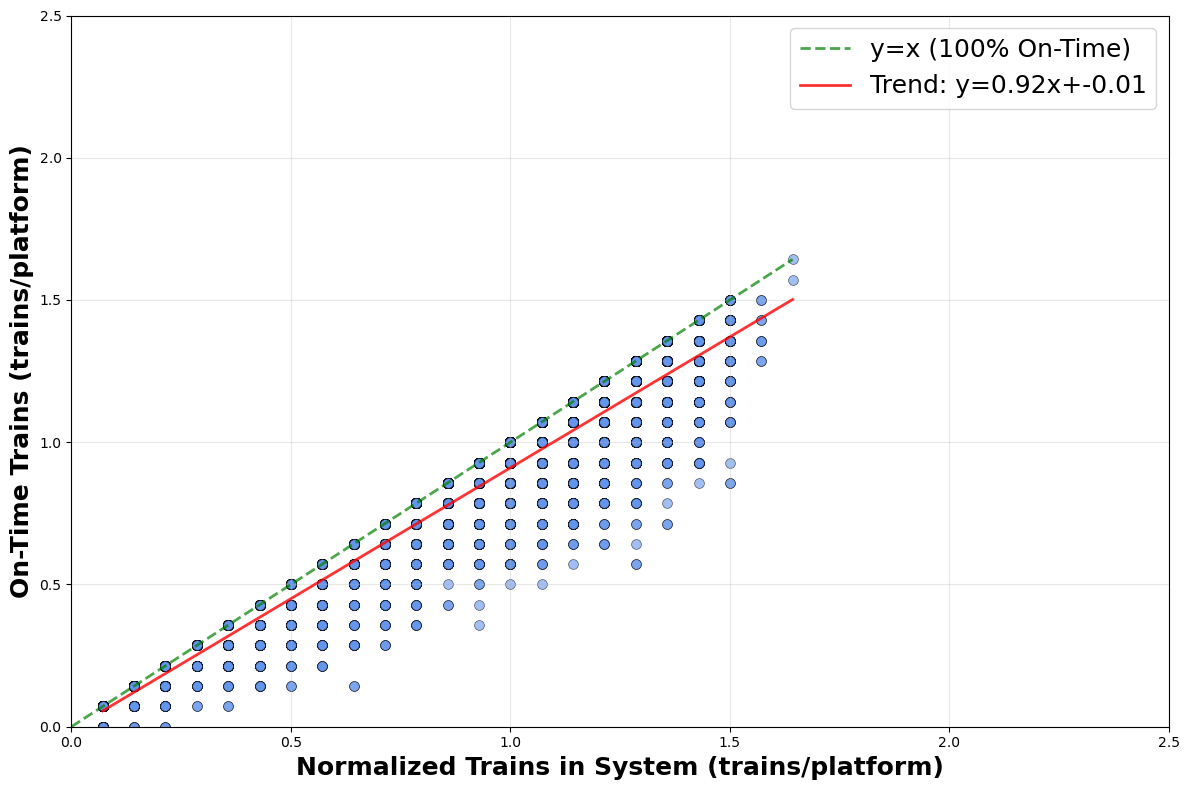


📈 ON-TIME PERFORMANCE STATISTICS - STATION 32000

📊 OVERALL STATISTICS:
  - Mean on-time trains per platform: 0.818 trains/platform
  - Median on-time trains per platform: 0.929 trains/platform
  - Min on-time trains per platform: 0.000 trains/platform
  - Max on-time trains per platform: 1.643 trains/platform
  - Mean total trains per platform: 0.900 trains/platform
  - Overall on-time percentage: 90.91% (86049/94652 trains)

🔍 CORRELATION ANALYSIS:
  - Correlation (total load vs on-time trains): 0.966

🔍 HIGH LOAD ANALYSIS (>1.0 trains/platform):
  - Hours in high load: 3559 (47.4%)
  - Mean on-time trains/platform in high load: 1.127
  - Mean total trains/platform in high load: 1.234

🔍 LOW LOAD ANALYSIS (≤0.5 trains/platform):
  - Hours in low load: 1592 (21.2%)
  - Mean on-time trains/platform in low load: 0.208
  - Mean total trains/platform in low load: 0.237
🎯 ON-TIME PERFORMANCE HISTOGRAM FOR STATION 32000
📊 Percentage of hours with 100% on-time performance by system load
✅ P

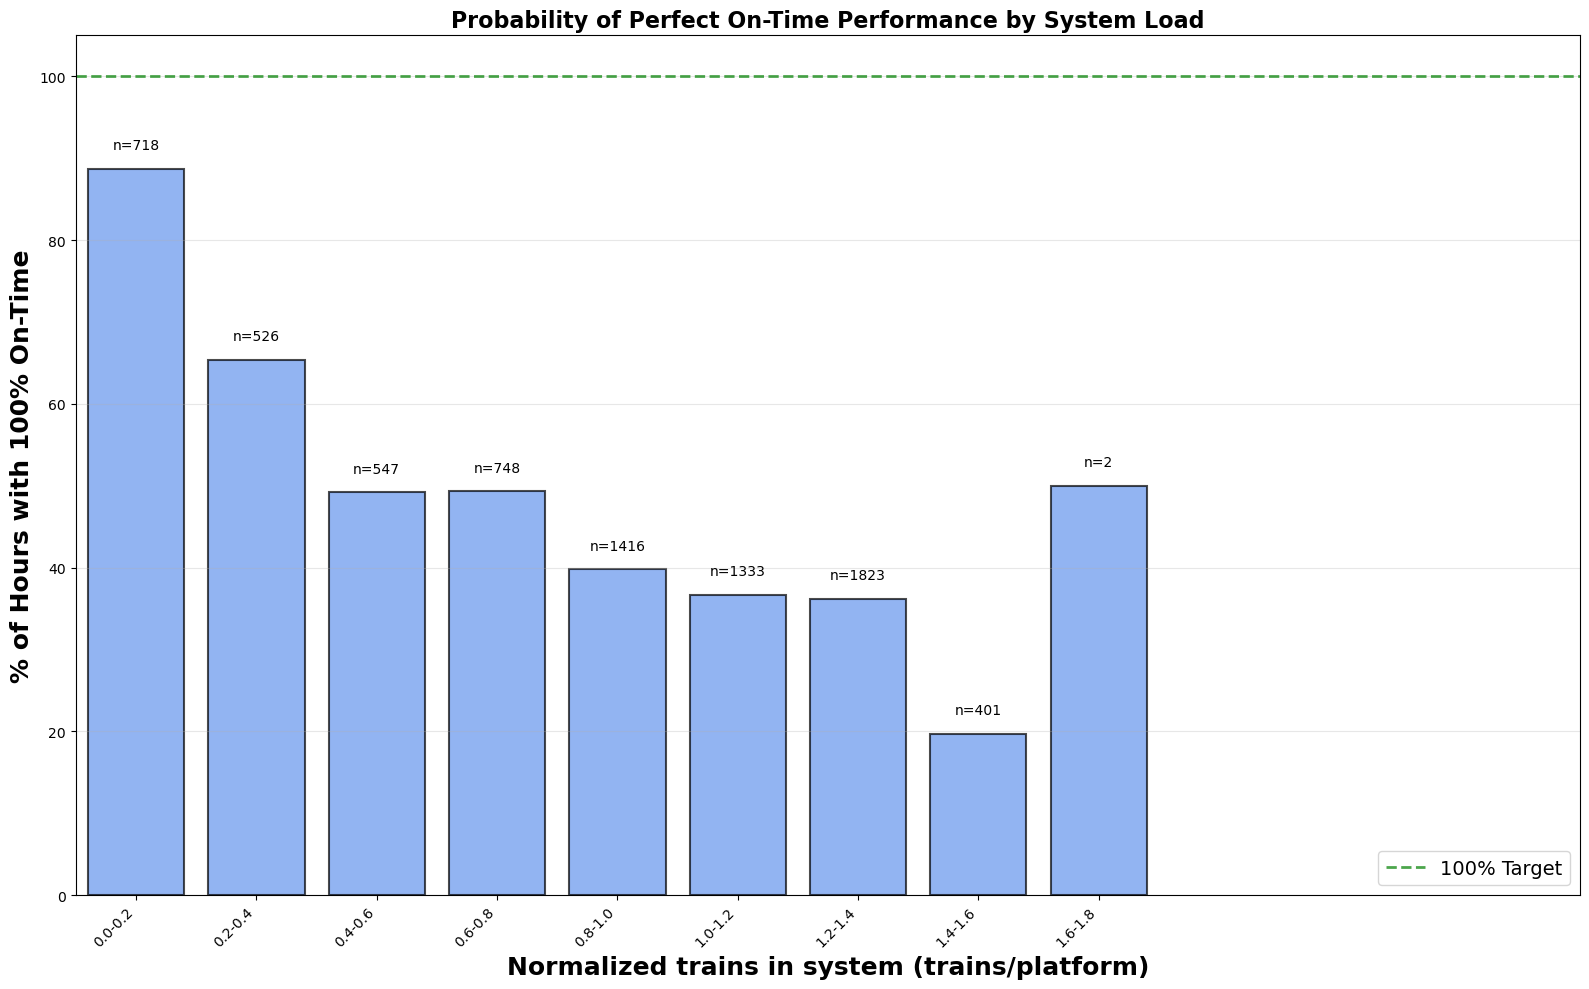


📈 ON-TIME PERFORMANCE BY SYSTEM LOAD - STATION 32000

📊 OVERALL STATISTICS:
  - Total hours analyzed: 7514
  - Hours with 100% on-time: 3412 (45.4%)
  - Mean on-time ratio: 0.905 (90.5%)

🏆 LOAD LEVEL WITH HIGHEST % OF PERFECT HOURS:
  - Load: 0.0-0.2 trains/platform
  - % hours with 100% on-time: 88.7%
  - Hours observed: 718

⚠️  LOAD LEVEL WITH LOWEST % OF PERFECT HOURS:
  - Load: 1.4-1.6 trains/platform
  - % hours with 100% on-time: 19.7%
  - Hours observed: 401
🎯 ON-TIME PERFORMANCE DISTRIBUTION (WEEKLY) FOR STATION 32000
📊 Histogram of weekly on-time percentages
✅ Processed 49 weeks of data
✅ Processed 49 weeks of data


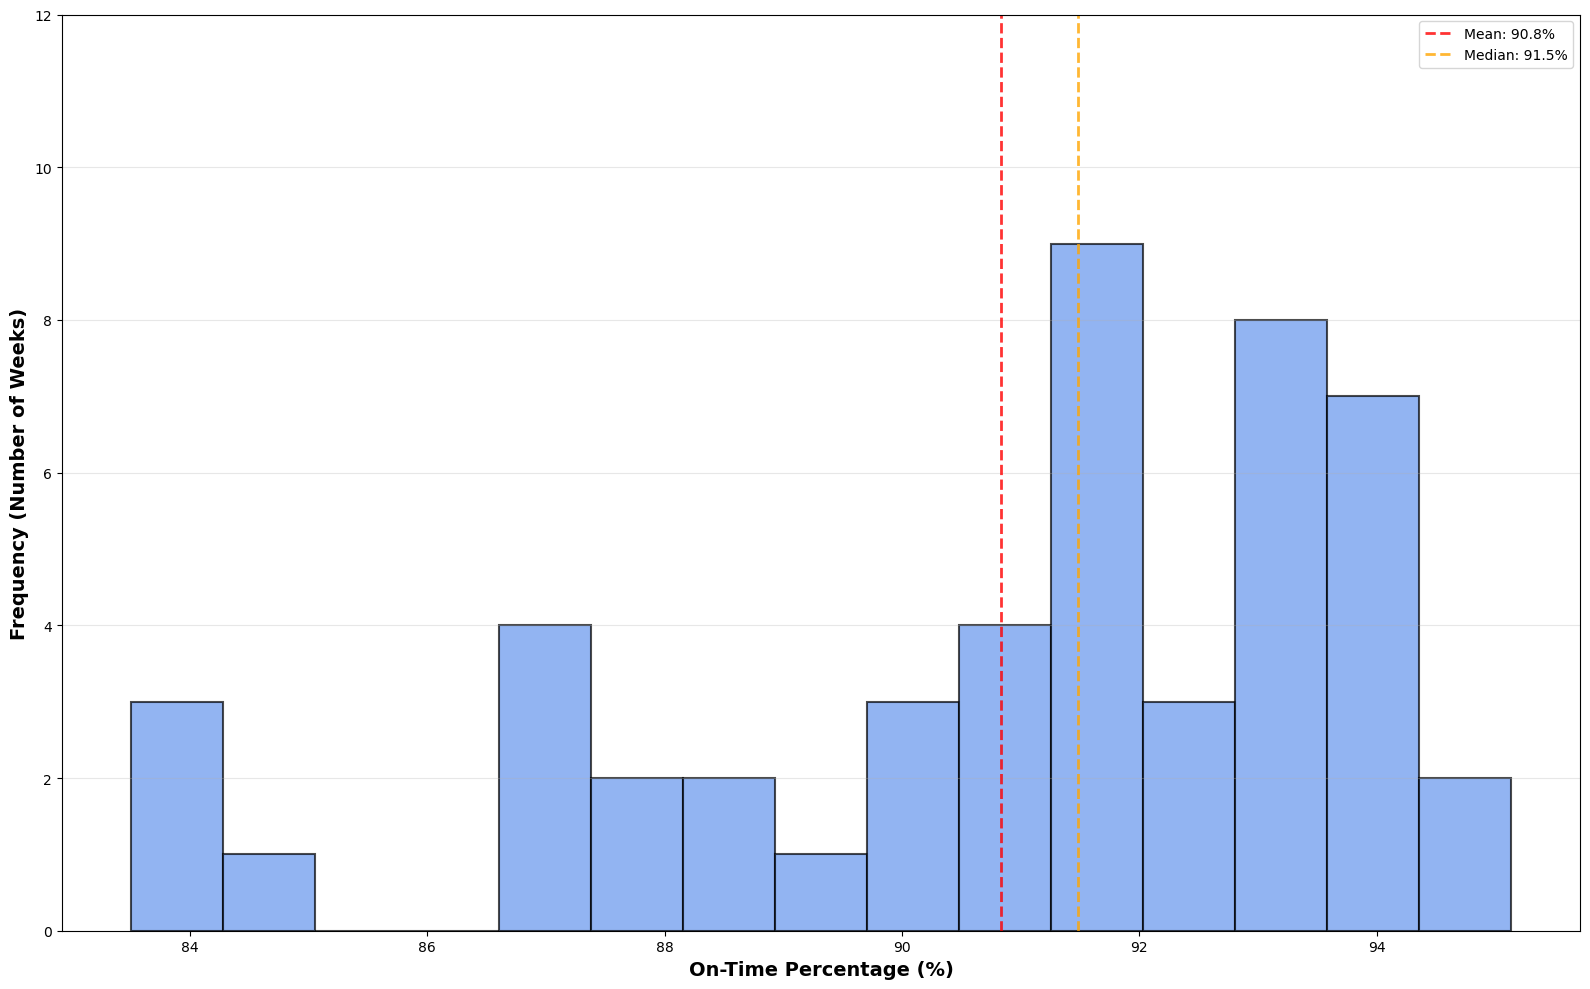


📈 WEEKLY ON-TIME PERCENTAGE DISTRIBUTION - STATION 32000

📊 DISTRIBUTION STATISTICS:
  - Mean: 90.84%
  - Median: 91.49%
  - Std dev: 3.06%
  - Min: 83.51%
  - Max: 95.13%
  - 25th percentile: 89.61%
  - 75th percentile: 93.12%

📊 PERFORMANCE CATEGORIES:
  - Excellent (≥95%): 1 weeks (2.0%)
  - Good (85-95%): 44 weeks (89.8%)
  - Fair (75-85%): 4 weeks (8.2%)
  - Poor (<75%): 0 weeks (0.0%)


In [193]:
# Example: Run the on-time performance analysis for Manchester Piccadilly
ontime_stats_32000 = plot_ontime_performance_vs_load(
    station_id='32000',
    all_data=all_data,
    num_platforms=14,
    dwell_time_minutes=5,
    figsize=(12, 8)
)

# Timeline for Manchester Piccadilly
weekly_stats_32000 = plot_ontime_performance_histogram(
    station_id='32000',
    all_data=all_data,
    num_platforms=14,
    dwell_time_minutes=5,
    figsize=(16, 10)
)

ontime_timeline_32000= plot_ontime_timeline_histogram(
    station_id='32000',
    all_data=all_data,
    num_platforms=14,
    dwell_time_minutes=5,
    figsize=(16, 10)
)

🎯 ON-TIME PERFORMANCE ANALYSIS FOR STATION 70261
📊 Focus: On-time trains (PFPI_MINUTES = 0.0 or NaN) vs System Load
✅ Processed 7078 hours with on-time statistics

🔍 DIAGNOSTIC INFORMATION
Date range: 2024-02-04 08:00:00 to 2025-01-05 00:00:00
Time span: 335 days

Total trains statistics:
  - Min total trains: 1
  - Max total trains: 10
  - Unique total train counts: 10

On-time trains statistics:
  - Min on-time trains: 0
  - Max on-time trains: 9
  - Unique on-time train counts: 10

Normalized values:
  - Unique x-axis values (trains_in_system_normalized): 10
  - Unique y-axis values (ontime_trains_normalized): 10
  - Total unique (x,y) combinations: 44

📋 Sample of hourly data (first 10 hours):
         hour_start  total_trains  ontime_trains_count  trains_in_system_normalized  ontime_trains_normalized
2024-02-04 08:00:00             2                    2                     0.285714                  0.285714
2024-02-04 10:00:00             4                    4                   

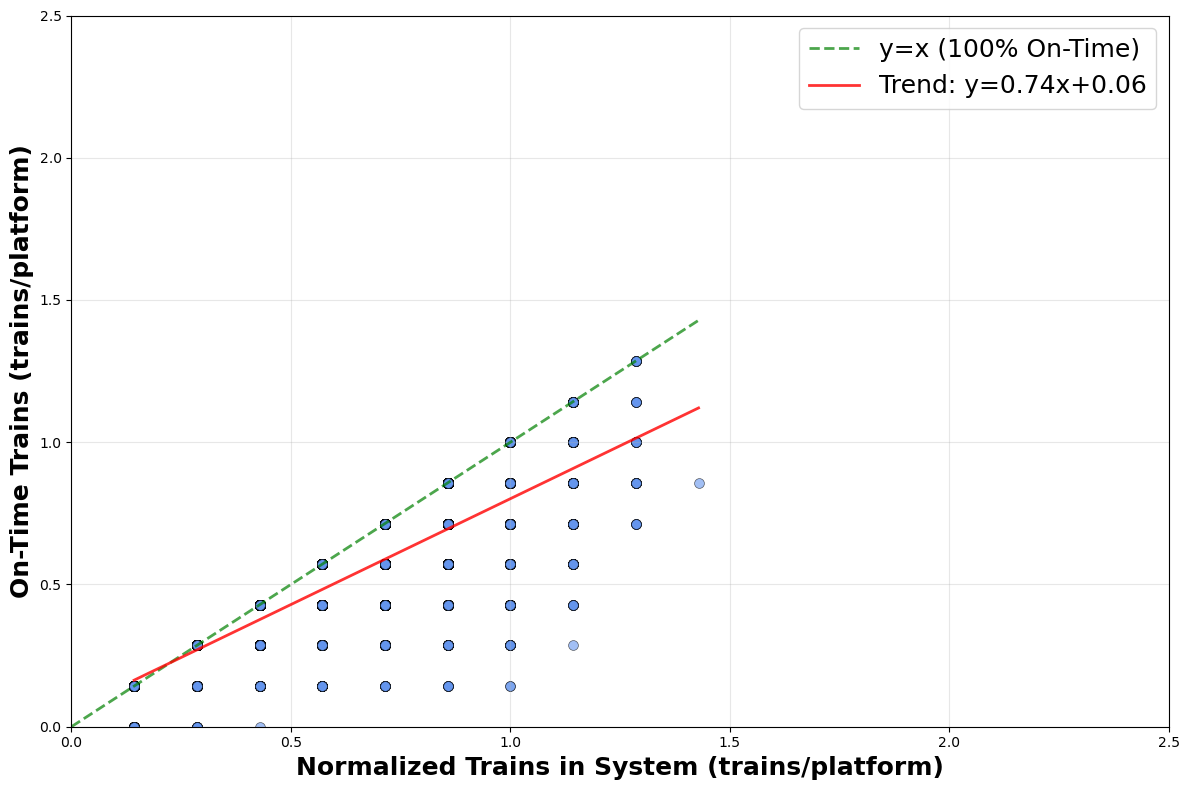


📈 ON-TIME PERFORMANCE STATISTICS - STATION 70261

📊 OVERALL STATISTICS:
  - Mean on-time trains per platform: 0.498 trains/platform
  - Median on-time trains per platform: 0.571 trains/platform
  - Min on-time trains per platform: 0.000 trains/platform
  - Max on-time trains per platform: 1.286 trains/platform
  - Mean total trains per platform: 0.593 trains/platform
  - Overall on-time percentage: 84.10% (24691/29359 trains)

🔍 CORRELATION ANALYSIS:
  - Correlation (total load vs on-time trains): 0.853

🔍 HIGH LOAD ANALYSIS (>1.0 trains/platform):
  - Hours in high load: 185 (2.6%)
  - Mean on-time trains/platform in high load: 0.886
  - Mean total trains/platform in high load: 1.171

🔍 LOW LOAD ANALYSIS (≤0.5 trains/platform):
  - Hours in low load: 2446 (34.6%)
  - Mean on-time trains/platform in low load: 0.265
  - Mean total trains/platform in low load: 0.289
🎯 ON-TIME PERFORMANCE HISTOGRAM FOR STATION 70261
📊 Percentage of hours with 100% on-time performance by system load
✅ Pro

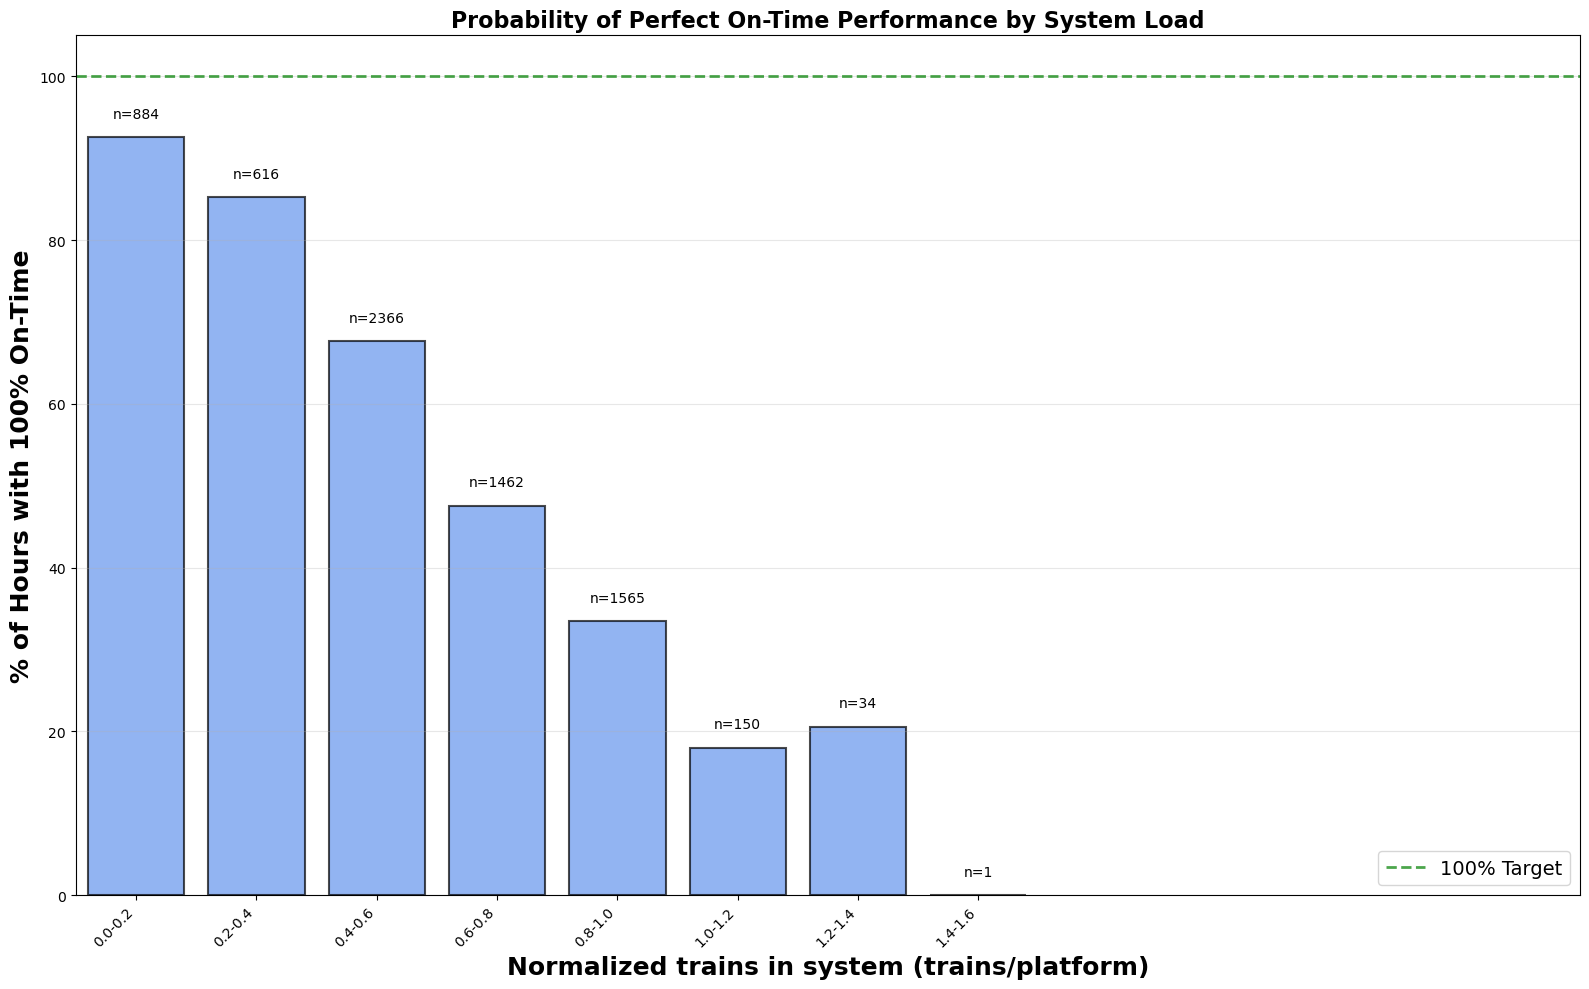


📈 ON-TIME PERFORMANCE BY SYSTEM LOAD - STATION 70261

📊 OVERALL STATISTICS:
  - Total hours analyzed: 7078
  - Hours with 100% on-time: 4196 (59.3%)
  - Mean on-time ratio: 0.864 (86.4%)

🏆 LOAD LEVEL WITH HIGHEST % OF PERFECT HOURS:
  - Load: 0.0-0.2 trains/platform
  - % hours with 100% on-time: 92.5%
  - Hours observed: 884

⚠️  LOAD LEVEL WITH LOWEST % OF PERFECT HOURS:
  - Load: 1.4-1.6 trains/platform
  - % hours with 100% on-time: 0.0%
  - Hours observed: 1
🎯 ON-TIME PERFORMANCE DISTRIBUTION (WEEKLY) FOR STATION 70261
📊 Histogram of weekly on-time percentages
✅ Processed 49 weeks of data
✅ Processed 49 weeks of data


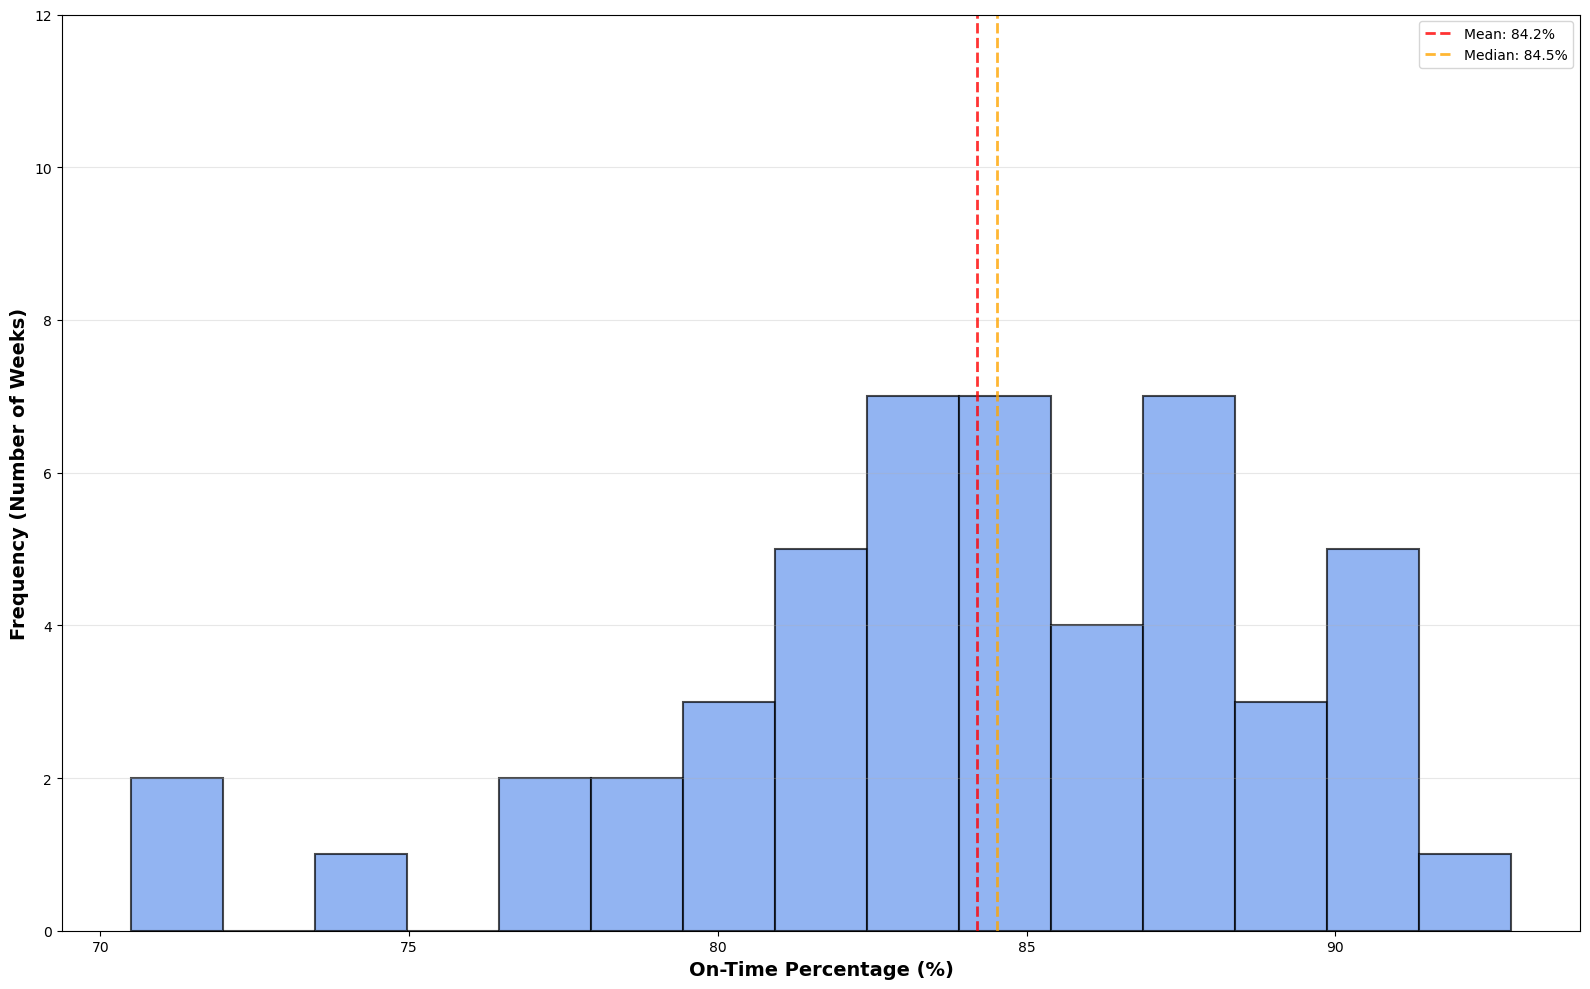


📈 WEEKLY ON-TIME PERCENTAGE DISTRIBUTION - STATION 70261

📊 DISTRIBUTION STATISTICS:
  - Mean: 84.20%
  - Median: 84.53%
  - Std dev: 4.90%
  - Min: 70.50%
  - Max: 92.84%
  - 25th percentile: 81.83%
  - 75th percentile: 87.82%

📊 PERFORMANCE CATEGORIES:
  - Excellent (≥95%): 0 weeks (0.0%)
  - Good (85-95%): 21 weeks (42.9%)
  - Fair (75-85%): 25 weeks (51.0%)
  - Poor (<75%): 3 weeks (6.1%)


In [194]:
# Example: Run the on-time performance analysis for Milton Keynes Central
ontime_stats_70261 = plot_ontime_performance_vs_load(
    station_id='70261',
    all_data=all_data,
    num_platforms=7,
    dwell_time_minutes=5,
    figsize=(12, 8)
)

ontime_histogram_70261 = plot_ontime_performance_histogram(
    station_id='70261',
    all_data=all_data,
    num_platforms=7,
    dwell_time_minutes=5,
    figsize=(16, 10)
)

ontime_timeline_70261= plot_ontime_timeline_histogram(
    station_id='70261',
    all_data=all_data,
    num_platforms=7,
    dwell_time_minutes=5,
    figsize=(16, 10)
)

🎯 ON-TIME PERFORMANCE ANALYSIS FOR STATION 33087
📊 Focus: On-time trains (PFPI_MINUTES = 0.0 or NaN) vs System Load
✅ Processed 6561 hours with on-time statistics
✅ Processed 6561 hours with on-time statistics


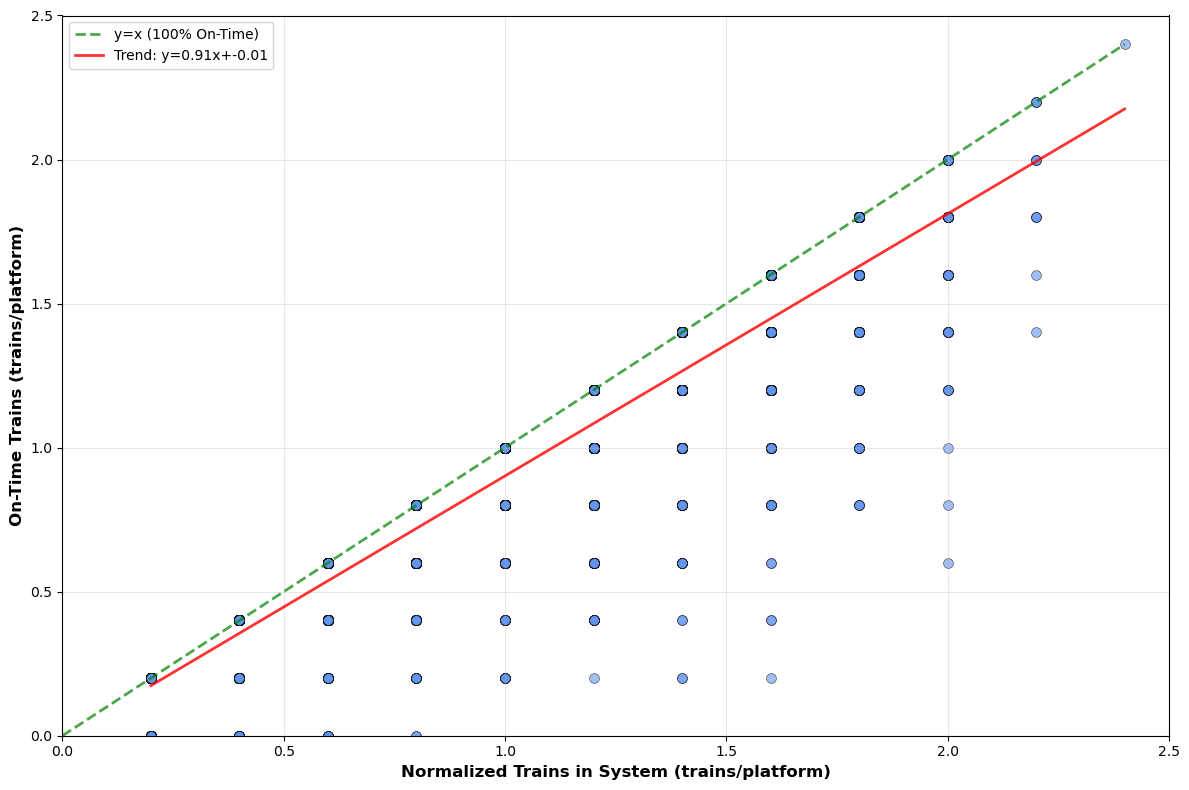


📈 ON-TIME PERFORMANCE STATISTICS - STATION 33087

📊 OVERALL STATISTICS:
  - Mean on-time trains per platform: 0.935 trains/platform
  - Median on-time trains per platform: 1.000 trains/platform
  - Min on-time trains per platform: 0.000 trains/platform
  - Max on-time trains per platform: 2.400 trains/platform
  - Mean total trains per platform: 1.037 trains/platform
  - Overall on-time percentage: 90.20% (30684/34016 trains)

🔍 CORRELATION ANALYSIS:
  - Correlation (total load vs on-time trains): 0.927

🔍 HIGH LOAD ANALYSIS (>1.0 trains/platform):
  - Hours in high load: 3172 (48.3%)
  - Mean on-time trains/platform in high load: 1.280
  - Mean total trains/platform in high load: 1.415

🔍 LOW LOAD ANALYSIS (≤0.5 trains/platform):
  - Hours in low load: 971 (14.8%)
  - Mean on-time trains/platform in low load: 0.249
  - Mean total trains/platform in low load: 0.291


In [ ]:
# Example: Run the on-time performance analysis for Manchester Oxford Road
ontime_stats_33087 = plot_ontime_performance_vs_load(
    station_id='33087',
    all_data=all_data,
    num_platforms=5,
    dwell_time_minutes=5,
    figsize=(12, 8)
)

For 'best' stations

🎯 ON-TIME PERFORMANCE ANALYSIS FOR STATION 51531
📊 Focus: On-time trains (PFPI_MINUTES = 0.0 or NaN) vs System Load
✅ Processed 6347 hours with on-time statistics

🔍 DIAGNOSTIC INFORMATION
Date range: 2024-02-04 00:00:00 to 2025-01-05 21:00:00
Time span: 336 days

Total trains statistics:
  - Min total trains: 1
  - Max total trains: 7
  - Unique total train counts: 7

On-time trains statistics:
  - Min on-time trains: 0
  - Max on-time trains: 7
  - Unique on-time train counts: 8

Normalized values:
  - Unique x-axis values (trains_in_system_normalized): 7
  - Unique y-axis values (ontime_trains_normalized): 8
  - Total unique (x,y) combinations: 24

📋 Sample of hourly data (first 10 hours):
         hour_start  total_trains  ontime_trains_count  trains_in_system_normalized  ontime_trains_normalized
2024-02-04 00:00:00             1                    1                     0.333333                  0.333333
2024-02-04 06:00:00             1                    1                     0.3

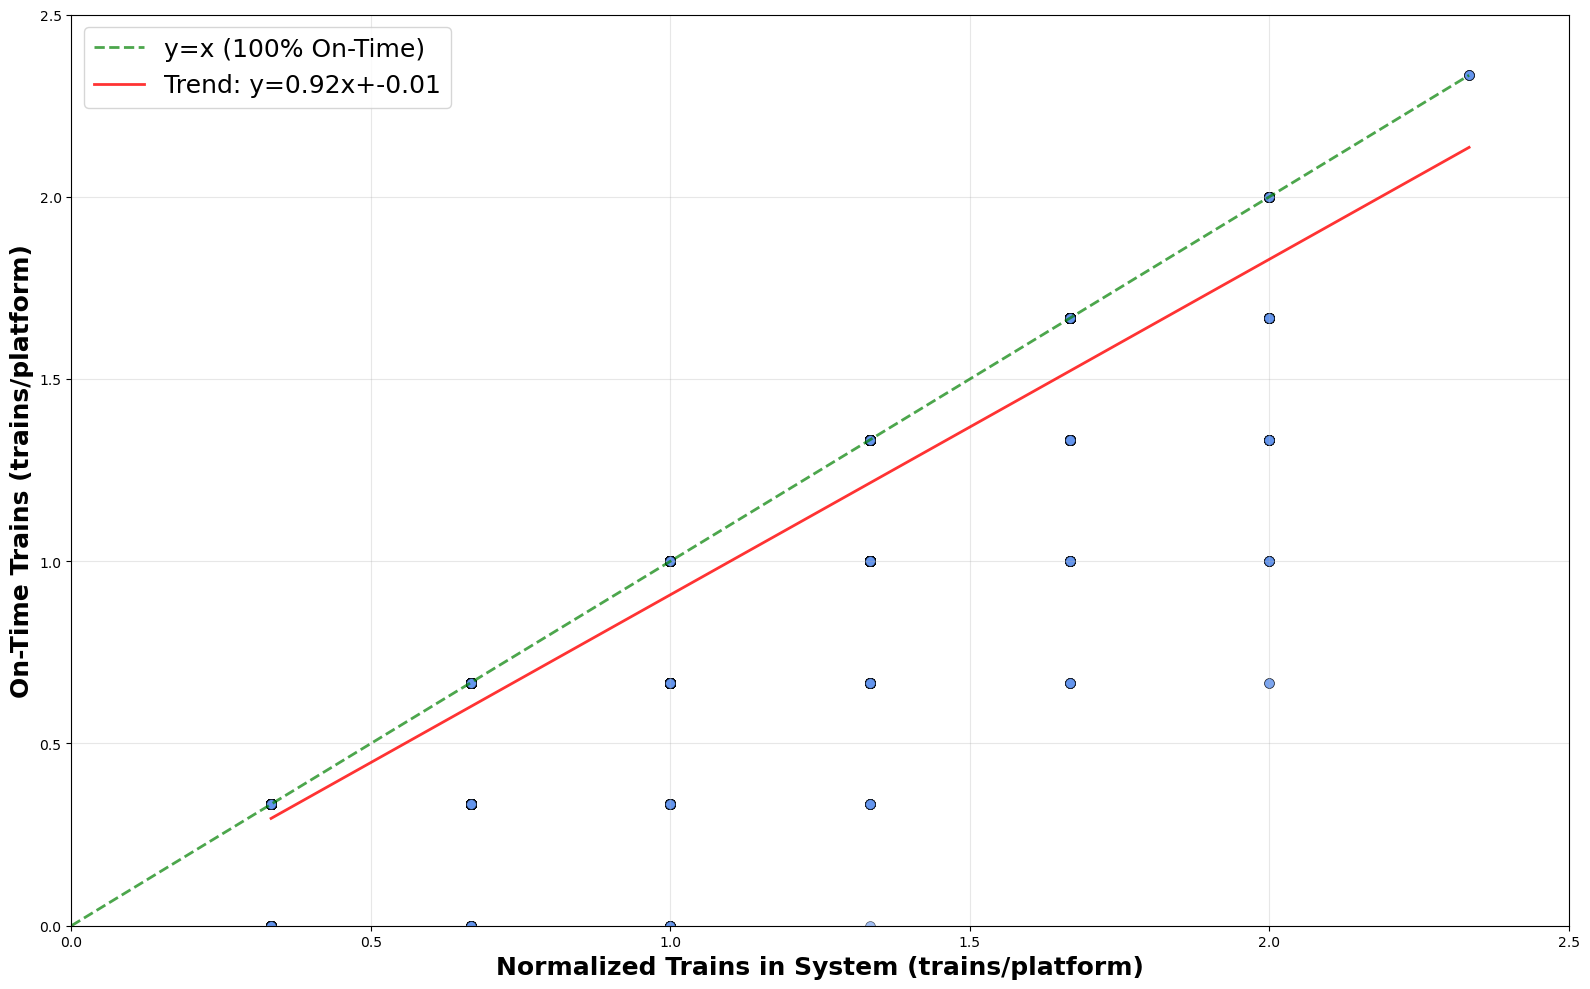


📈 ON-TIME PERFORMANCE STATISTICS - STATION 51531

📊 OVERALL STATISTICS:
  - Mean on-time trains per platform: 0.824 trains/platform
  - Median on-time trains per platform: 0.667 trains/platform
  - Min on-time trains per platform: 0.000 trains/platform
  - Max on-time trains per platform: 2.333 trains/platform
  - Mean total trains per platform: 0.908 trains/platform
  - Overall on-time percentage: 90.68% (15682/17293 trains)

🔍 CORRELATION ANALYSIS:
  - Correlation (total load vs on-time trains): 0.915

🔍 HIGH LOAD ANALYSIS (>1.0 trains/platform):
  - Hours in high load: 1752 (27.6%)
  - Mean on-time trains/platform in high load: 1.367
  - Mean total trains/platform in high load: 1.491

🔍 LOW LOAD ANALYSIS (≤0.5 trains/platform):
  - Hours in low load: 1350 (21.3%)
  - Mean on-time trains/platform in low load: 0.295
  - Mean total trains/platform in low load: 0.333
🎯 ON-TIME PERFORMANCE HISTOGRAM FOR STATION 51531
📊 Percentage of hours with 100% on-time performance by system load
✅ P

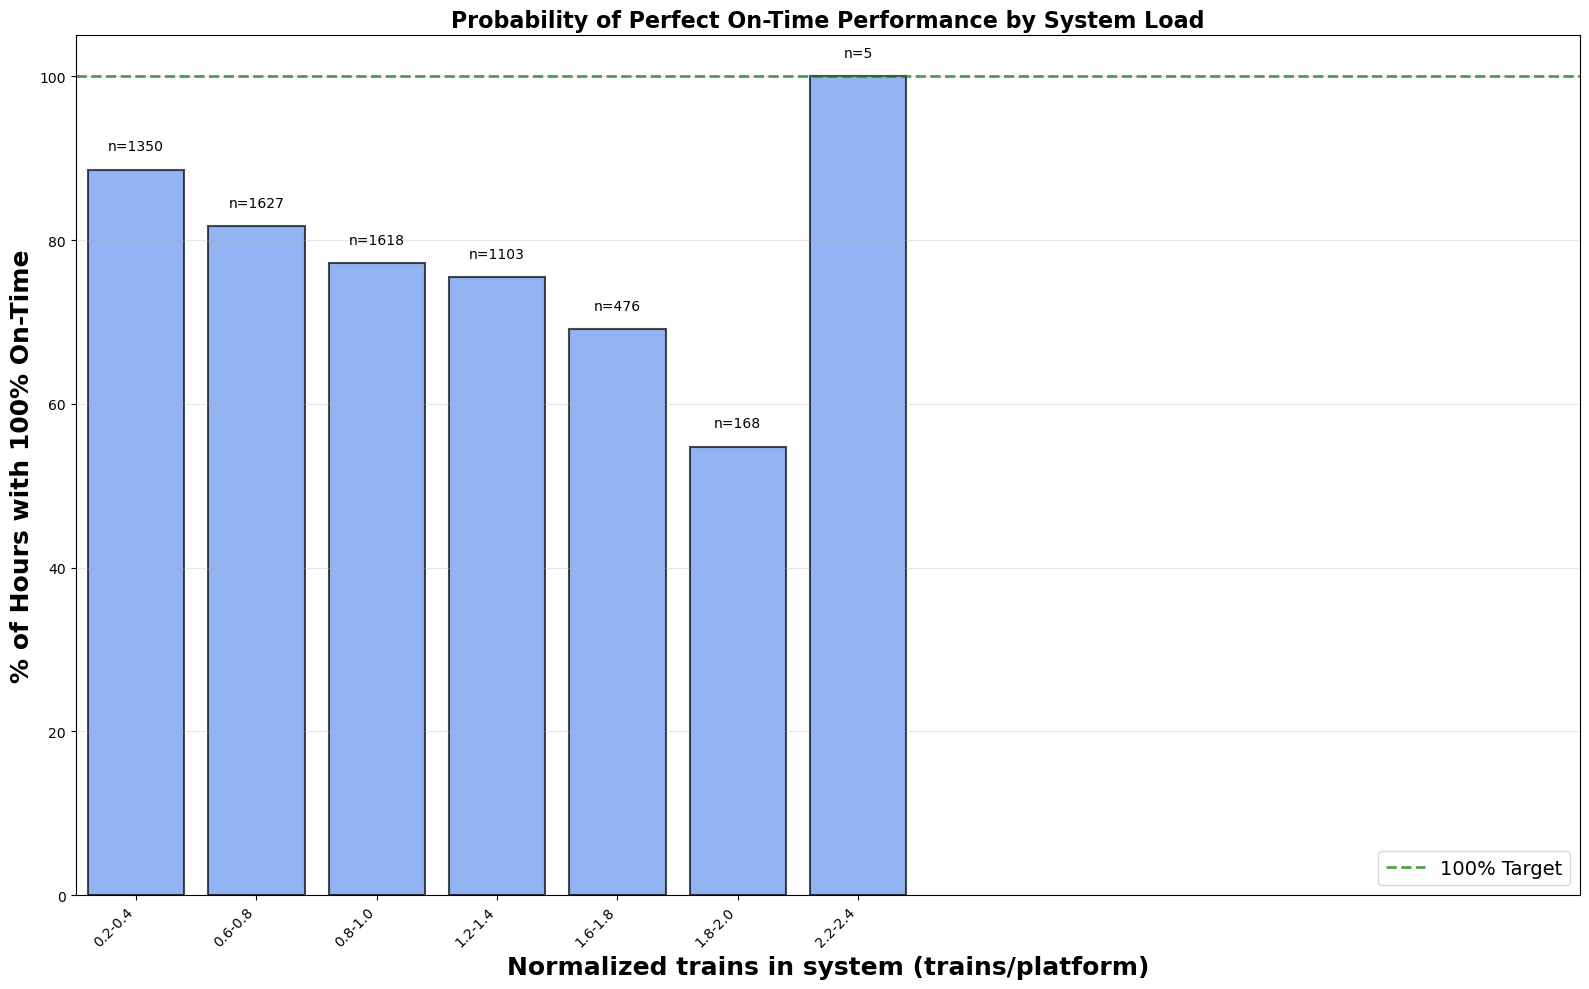


📈 ON-TIME PERFORMANCE BY SYSTEM LOAD - STATION 51531

📊 OVERALL STATISTICS:
  - Total hours analyzed: 6347
  - Hours with 100% on-time: 5032 (79.3%)
  - Mean on-time ratio: 0.902 (90.2%)

🏆 LOAD LEVEL WITH HIGHEST % OF PERFECT HOURS:
  - Load: 2.2-2.4 trains/platform
  - % hours with 100% on-time: 100.0%
  - Hours observed: 5

⚠️  LOAD LEVEL WITH LOWEST % OF PERFECT HOURS:
  - Load: 1.8-2.0 trains/platform
  - % hours with 100% on-time: 54.8%
  - Hours observed: 168
🎯 ON-TIME PERFORMANCE DISTRIBUTION (WEEKLY) FOR STATION 51531
📊 Histogram of weekly on-time percentages
✅ Processed 49 weeks of data
✅ Processed 49 weeks of data


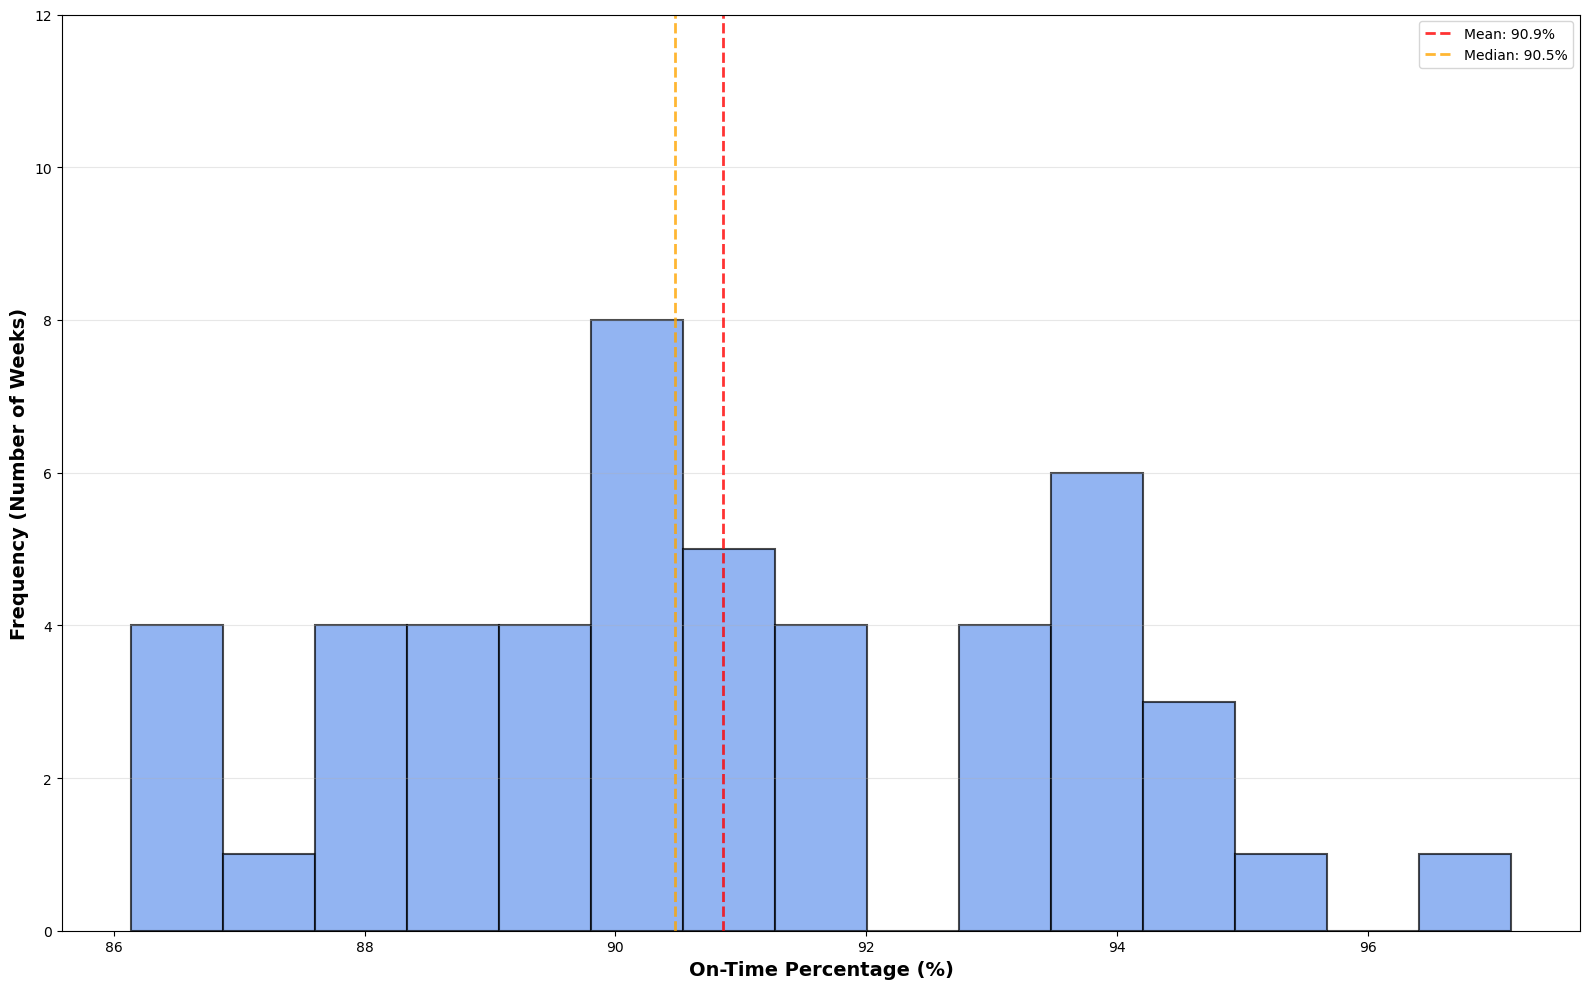


📈 WEEKLY ON-TIME PERCENTAGE DISTRIBUTION - STATION 51531

📊 DISTRIBUTION STATISTICS:
  - Mean: 90.86%
  - Median: 90.48%
  - Std dev: 2.63%
  - Min: 86.14%
  - Max: 97.14%
  - 25th percentile: 88.98%
  - 75th percentile: 93.24%

📊 PERFORMANCE CATEGORIES:
  - Excellent (≥95%): 2 weeks (4.1%)
  - Good (85-95%): 47 weeks (95.9%)
  - Fair (75-85%): 0 weeks (0.0%)
  - Poor (<75%): 0 weeks (0.0%)


In [190]:
# Run the on-time analysis for Barking (9 plts, 3 only for NWR)
ountime_stats_51531 = plot_ontime_performance_vs_load(
    station_id='51531',
    all_data=all_data,
    num_platforms=3,
    dwell_time_minutes=5,
    figsize=(16, 10)
)

ontime_histogram_51531 = plot_ontime_performance_histogram(
    station_id='51531',
    all_data=all_data,
    num_platforms=3,
    dwell_time_minutes=5,
    figsize=(16, 10)
)   

ontime_timeline_51531= plot_ontime_timeline_histogram(
    station_id='51531',
    all_data=all_data,
    num_platforms=3,
    dwell_time_minutes=5,
    figsize=(16, 10)
)

🎯 ON-TIME PERFORMANCE ANALYSIS FOR STATION 88403
📊 Focus: On-time trains (PFPI_MINUTES = 0.0 or NaN) vs System Load
✅ Processed 5210 hours with on-time statistics

🔍 DIAGNOSTIC INFORMATION
Date range: 2024-02-04 00:00:00 to 2025-01-04 23:00:00
Time span: 335 days

Total trains statistics:
  - Min total trains: 1
  - Max total trains: 13
  - Unique total train counts: 13

On-time trains statistics:
  - Min on-time trains: 0
  - Max on-time trains: 9
  - Unique on-time train counts: 10

Normalized values:
  - Unique x-axis values (trains_in_system_normalized): 13
  - Unique y-axis values (ontime_trains_normalized): 10
  - Total unique (x,y) combinations: 71

📋 Sample of hourly data (first 10 hours):
         hour_start  total_trains  ontime_trains_count  trains_in_system_normalized  ontime_trains_normalized
2024-02-04 00:00:00             1                    1                     0.142857                  0.142857
2024-02-04 07:00:00             2                    2                   

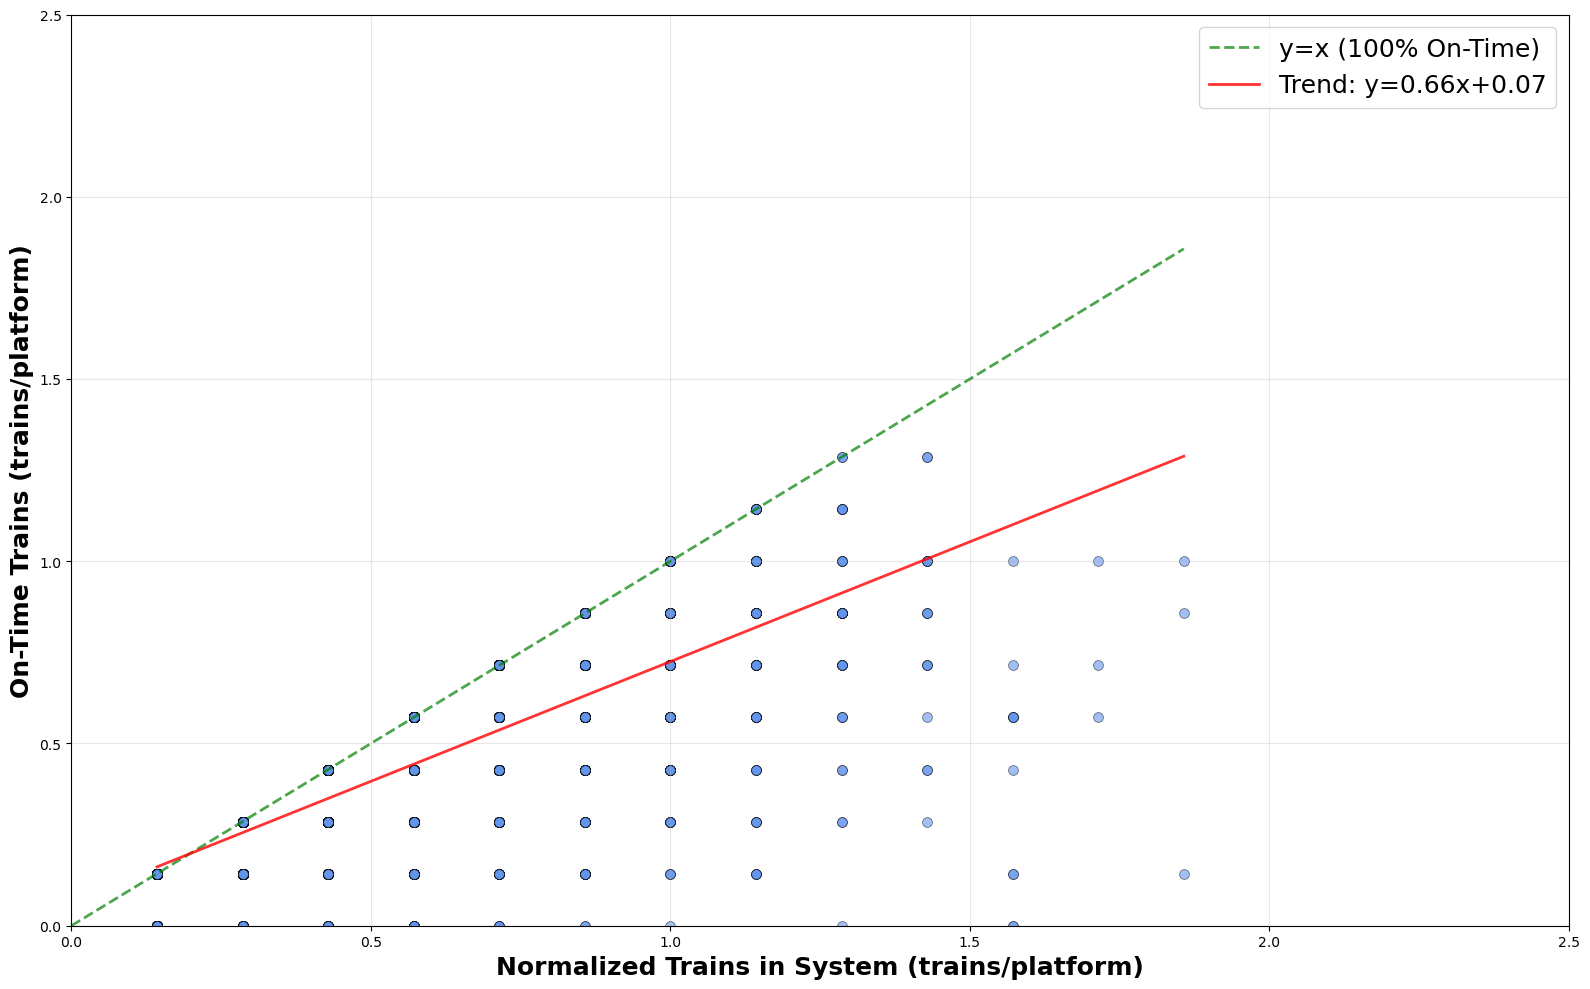


📈 ON-TIME PERFORMANCE STATISTICS - STATION 88403

📊 OVERALL STATISTICS:
  - Mean on-time trains per platform: 0.336 trains/platform
  - Median on-time trains per platform: 0.286 trains/platform
  - Min on-time trains per platform: 0.000 trains/platform
  - Max on-time trains per platform: 1.286 trains/platform
  - Mean total trains per platform: 0.409 trains/platform
  - Overall on-time percentage: 82.24% (12270/14919 trains)

🔍 CORRELATION ANALYSIS:
  - Correlation (total load vs on-time trains): 0.816

🔍 HIGH LOAD ANALYSIS (>1.0 trains/platform):
  - Hours in high load: 142 (2.7%)
  - Mean on-time trains/platform in high load: 0.758
  - Mean total trains/platform in high load: 1.271

🔍 LOW LOAD ANALYSIS (≤0.5 trains/platform):
  - Hours in low load: 3695 (70.9%)
  - Mean on-time trains/platform in low load: 0.238
  - Mean total trains/platform in low load: 0.266
🎯 ON-TIME PERFORMANCE HISTOGRAM FOR STATION 88403
📊 Percentage of hours with 100% on-time performance by system load
✅ Pro

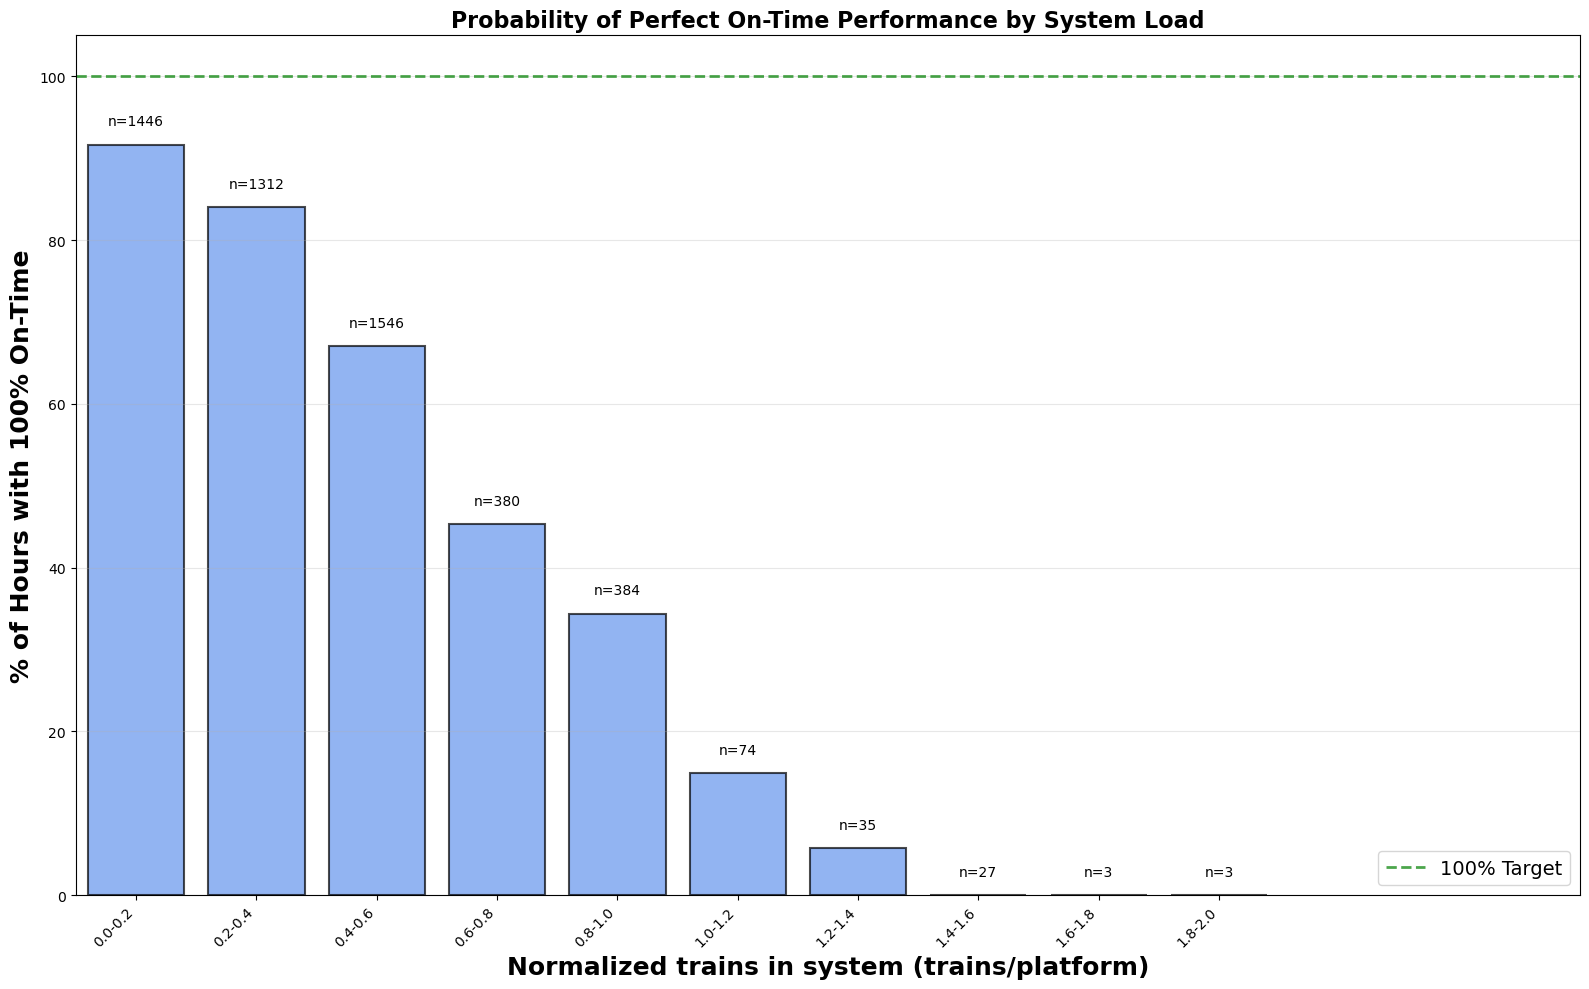


📈 ON-TIME PERFORMANCE BY SYSTEM LOAD - STATION 88403

📊 OVERALL STATISTICS:
  - Total hours analyzed: 5210
  - Hours with 100% on-time: 3780 (72.6%)
  - Mean on-time ratio: 0.866 (86.6%)

🏆 LOAD LEVEL WITH HIGHEST % OF PERFECT HOURS:
  - Load: 0.0-0.2 trains/platform
  - % hours with 100% on-time: 91.6%
  - Hours observed: 1446

⚠️  LOAD LEVEL WITH LOWEST % OF PERFECT HOURS:
  - Load: 1.4-1.6 trains/platform
  - % hours with 100% on-time: 0.0%
  - Hours observed: 27
🎯 ON-TIME PERFORMANCE DISTRIBUTION (WEEKLY) FOR STATION 88403
📊 Histogram of weekly on-time percentages
✅ Processed 49 weeks of data
✅ Processed 49 weeks of data


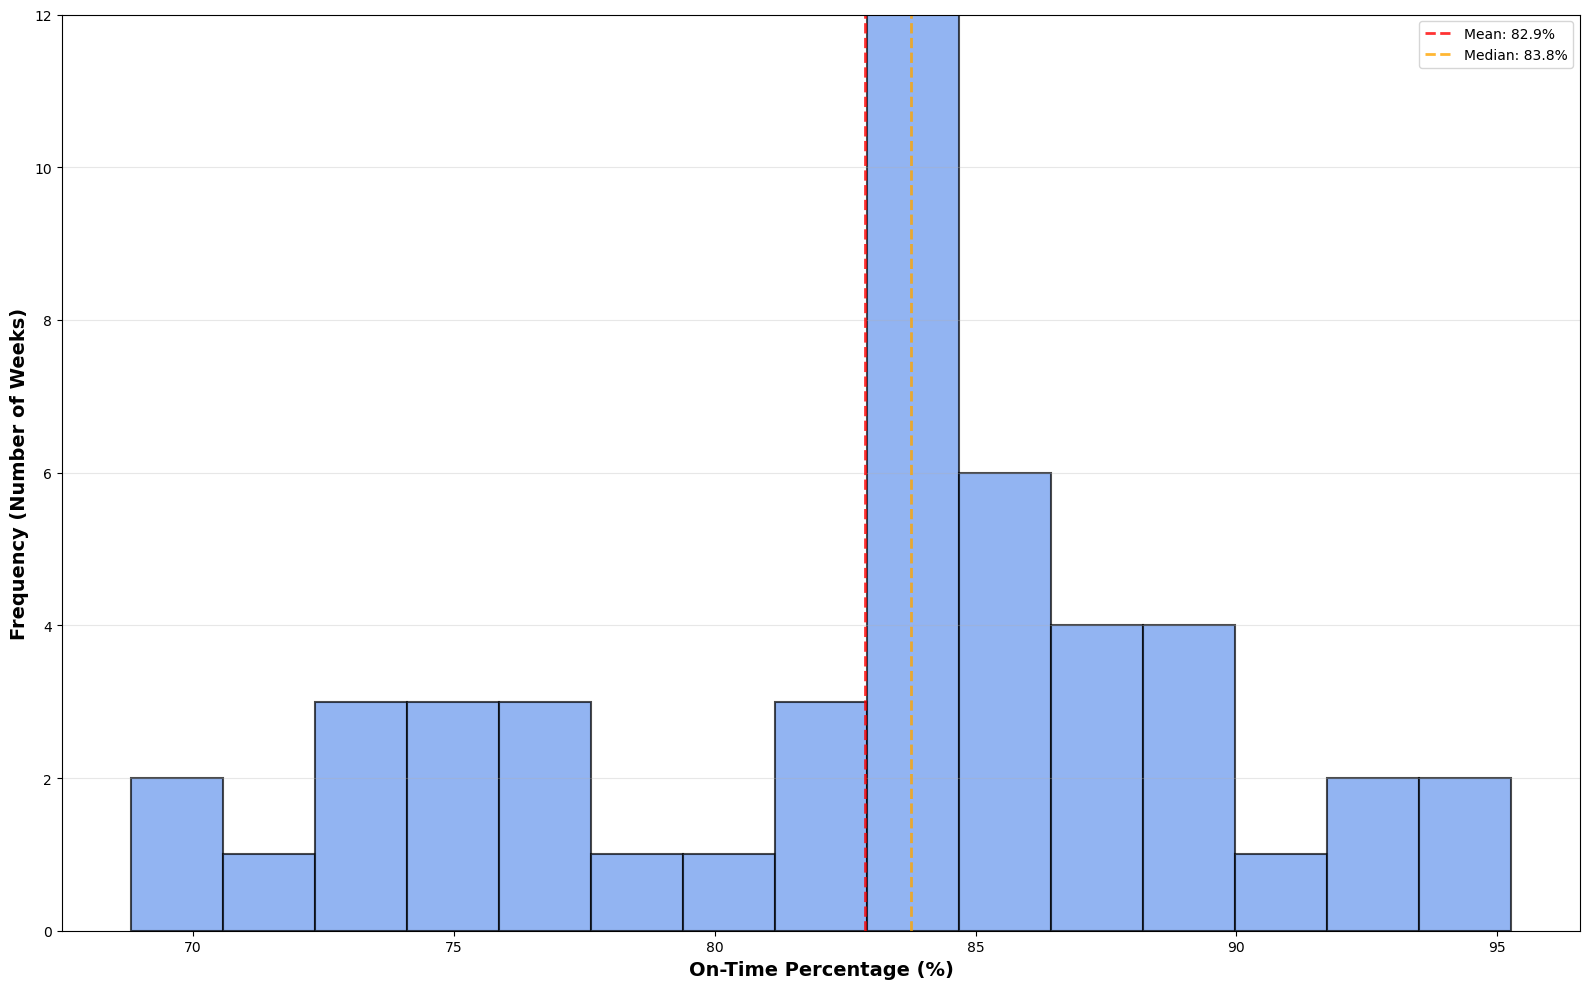


📈 WEEKLY ON-TIME PERCENTAGE DISTRIBUTION - STATION 88403

📊 DISTRIBUTION STATISTICS:
  - Mean: 82.87%
  - Median: 83.75%
  - Std dev: 6.40%
  - Min: 68.82%
  - Max: 95.26%
  - 25th percentile: 79.33%
  - 75th percentile: 86.92%

📊 PERFORMANCE CATEGORIES:
  - Excellent (≥95%): 2 weeks (4.1%)
  - Good (85-95%): 15 weeks (30.6%)
  - Fair (75-85%): 24 weeks (49.0%)
  - Poor (<75%): 8 weeks (16.3%)


In [191]:
# Run the on-time analysis for London Cannon Street (9 total, 7 NWR)
ontime_stats_88403 = plot_ontime_performance_vs_load(
    station_id='88403',
    all_data=all_data,
    num_platforms=7,
    dwell_time_minutes=5,
    figsize=(16, 10)
)

ontime_histogram_88403 = plot_ontime_performance_histogram(
    station_id='88403',
    all_data=all_data,
    num_platforms=7,
    dwell_time_minutes=5,
    figsize=(16, 10)
)

ontime_timeline_88403= plot_ontime_timeline_histogram(
    station_id='88403',
    all_data=all_data,
    num_platforms=7,
    dwell_time_minutes=5,
    figsize=(16, 10)
)

🎯 ON-TIME PERFORMANCE TIMELINE FOR STATION 32000
📊 Weekly on-time percentage over the year (aggregated from hourly data)
✅ Processed 49 weeks of data
Date range: 2024-01-29 00:00:00 to 2024-12-30 00:00:00
✅ Processed 49 weeks of data
Date range: 2024-01-29 00:00:00 to 2024-12-30 00:00:00


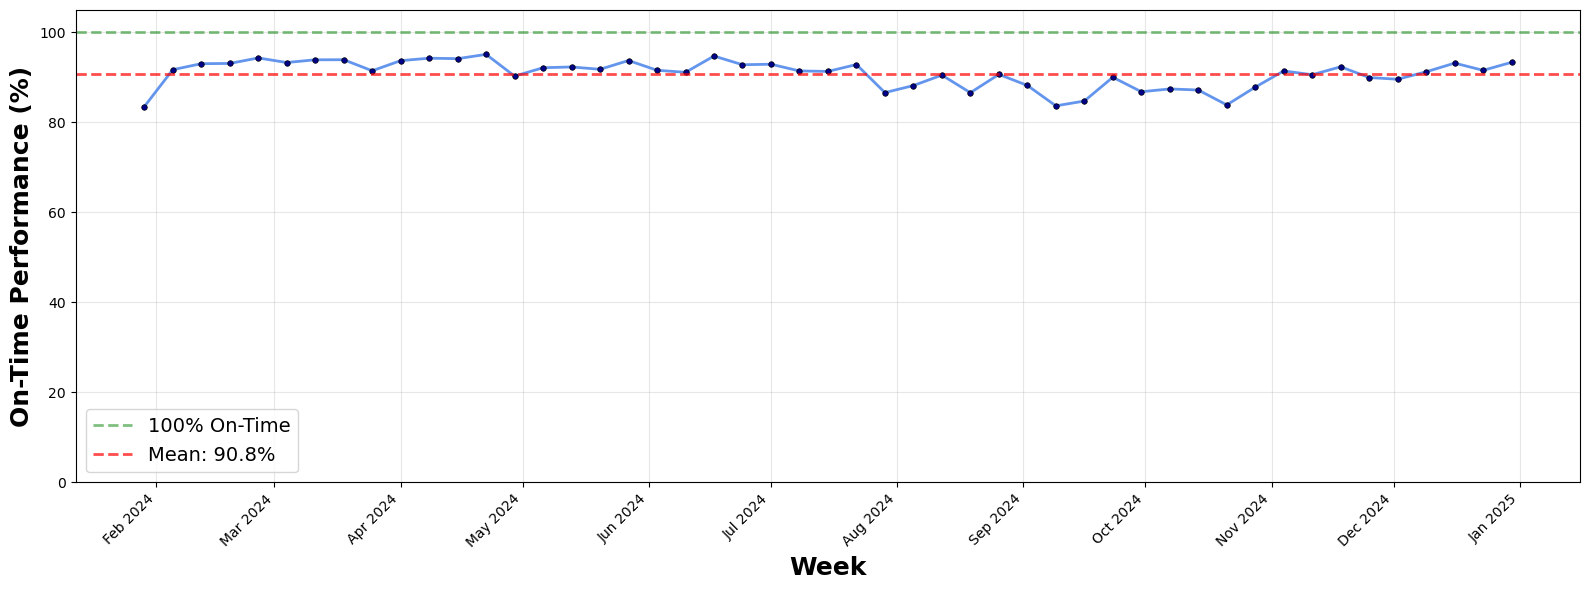


📈 WEEKLY ON-TIME PERFORMANCE STATISTICS - STATION 32000

📊 OVERALL STATISTICS:
  - Mean weekly on-time percentage: 90.84%
  - Median weekly on-time percentage: 91.49%
  - Min weekly on-time percentage: 83.51%
  - Max weekly on-time percentage: 95.13%
  - Std dev: 3.06%
  - Overall on-time percentage (unique trains): 90.91% (86049/94652 trains)


KeyError: 'ontime_arrivals'

In [192]:
# Timeline for Manchester Piccadilly (worst performing)
weekly_stats_32000 = plot_ontime_performance_timeline(
    station_id='32000',
    all_data=all_data,
    figsize=(16, 6)
)

In [ ]:
# Timeline for Barking (best performing)
weekly_stats_51531 = plot_ontime_performance_timeline(
    station_id='51531',
    all_data=all_data,
    figsize=(16, 6)
)

In [ ]:
# Timeline for London Cannon Street (best performing)
weekly_stats_88403 = plot_ontime_performance_timeline(
    station_id='88403',
    all_data=all_data,
    figsize=(16, 6)
)

## Histogram Versions - On-Time Performance Analysis

These histograms show the distribution of on-time performance from different perspectives:
- **Load-based histogram**: How on-time ratio varies across different system loads (train counts)
- **Timeline histogram**: Distribution of weekly on-time percentages over the year

### Histogram Analysis - 'Worst' Performing Stations

In [ ]:
# Histogram: Manchester Piccadilly - on-time ratio by system load
histogram_stats_32000 = plot_ontime_performance_histogram(
    station_id='32000',
    all_data=all_data,
    num_platforms=14,
    dwell_time_minutes=5,
    figsize=(14, 6)
)

In [ ]:
# Histogram: Manchester Piccadilly - weekly on-time percentage distribution
weekly_histogram_32000 = plot_ontime_timeline_histogram(
    station_id='32000',
    all_data=all_data,
    num_platforms=14,
    dwell_time_minutes=5,
    figsize=(14, 6)
)

### Histogram Analysis - 'Best' Performing Stations

In [ ]:
# Histogram: Barking - on-time ratio by system load
histogram_stats_51531 = plot_ontime_performance_histogram(
    station_id='51531',
    all_data=all_data,
    num_platforms=3,
    dwell_time_minutes=5,
    figsize=(14, 6)
)

In [ ]:
# Histogram: Barking - weekly on-time percentage distribution
weekly_histogram_51531 = plot_ontime_timeline_histogram(
    station_id='51531',
    all_data=all_data,
    num_platforms=3,
    dwell_time_minutes=5,
    figsize=(14, 6)
)

In [ ]:
# Histogram: London Cannon Street - on-time ratio by system load
histogram_stats_88403 = plot_ontime_performance_histogram(
    station_id='88403',
    all_data=all_data,
    num_platforms=7,
    dwell_time_minutes=5,
    figsize=(14, 6)
)

In [ ]:
# Histogram: London Cannon Street - weekly on-time percentage distribution
weekly_histogram_88403 = plot_ontime_timeline_histogram(
    station_id='88403',
    all_data=all_data,
    num_platforms=7,
    dwell_time_minutes=5,
    figsize=(14, 6)
)